# Import packages and data

In [1]:
import pickle
import warnings
from itertools import product, product as iter_product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import gaussian_kde

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    make_scorer,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    cross_validate,
    KFold,
    train_test_split,
)
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
# Read all simulation output CSV files
output_v500f_n_8 = pd.read_csv("data/output_v500f_n_8.csv")
output_2_v500f_n_8 = pd.read_csv("data/output_2_v500f_n_8.csv")
output_3_v500f_n_8 = pd.read_csv("data/output_3_v500f_n_8.csv")
output_v500f_n_10_1 = pd.read_csv("data/output_v500f_n_10_1.csv")
output_v500f_n_10_2 = pd.read_csv("data/output_v500f_n_10_2.csv")
output_t38_n_6 = pd.read_csv("data/output_t38_n_6.csv")
output_t38_n_8 = pd.read_csv("data/output_t38_n_8.csv")
output_t38_n_10 = pd.read_csv("data/output_t38_n_10.csv")

In [3]:
# Read the Matlab output
matlab_output = pd.read_csv("data/test_fixed_v12.xlsx - Matlab_output.csv")

In [4]:
print(matlab_output.shape)
matlab_output.head().style

(4923, 38)


,freq,Lcm,Ucm,Icm,Core Nr,Core Series,AL,permeability,OD,ID,H,AWG,WireOD,WireODbare,Nreq,TotalWires,Lob,Lsigma,Zdes,Zob,Bcmpk,Bpk,Pcore,Pwire,R_critical_mm,Circ_critical_mm,Circ_needed_mm,Circ_available_mm,Margin_mm,Insulator_arc_deg,Winding_angle_deg,Arc_per_wire_deg,R_inner_mm,Circ_inner_mm,Insulator_arc_length_mm,Phase_arc_length_mm,Turn_spacing_mm,PhysicalCheck
0,100000,0.001000,0.792780,0.001000,12,VP500F,0.000057,100000,0.022600,0.010300,0.010200,18,0.001095,0.001024,8,24,0.000876,0.000003,628.318500,792.777800,0.007366,0.661130,0.002282,23.221200,4.638000,29.141400,28.684500,29.141400,0.456960,10,110,12.650000,5.150000,32.358400,0.898840,9.887300,0.080000,TIGHT
1,100000,0.001000,0.713460,0.001000,15,VP500F,0.000067,100000,0.027900,0.013600,0.012500,15,0.001529,0.001450,7,21,0.000788,0.000003,628.318500,713.456600,0.005612,0.501540,0.002054,13.380000,6.075000,38.170400,35.070900,38.170400,3.099500,10,110,13.675500,6.800000,42.725700,1.186800,13.055100,0.080000,OK
2,100000,0.001000,0.713460,0.001000,15,VP500F,0.000067,100000,0.027900,0.013600,0.012500,16,0.001369,0.001291,7,21,0.000788,0.000003,628.318500,713.456600,0.005612,0.530760,0.002054,16.878800,6.154500,38.669900,31.773500,38.669900,6.896400,10,110,12.018700,6.800000,42.725700,1.186800,13.055100,0.080000,OK
3,100000,0.001000,0.931860,0.001000,15,VP500F,0.000067,100000,0.027900,0.013600,0.012500,16,0.001369,0.001291,8,24,0.001030,0.000004,628.318500,931.861700,0.004910,0.569100,0.002683,19.290000,6.154500,38.669900,35.886500,38.669900,2.783400,10,110,12.018700,6.800000,42.725700,1.186800,13.055100,0.080000,OK
4,100000,0.001000,0.713460,0.001000,15,VP500F,0.000067,100000,0.027900,0.013600,0.012500,17,0.001224,0.001150,7,21,0.000788,0.000003,628.318500,713.456600,0.005612,0.560880,0.002054,21.271500,6.206600,38.997100,28.839800,38.997100,10.157400,10,110,10.616200,6.800000,42.725700,1.186800,13.055100,0.080000,LOOSE


In [5]:
# Read permeability curves for VP500F and T38
permeability_v500f = pd.read_excel("data/permeabilitycurve_selected.xlsx", sheet_name="Ver500f")
permeability_t38 = pd.read_excel("data/permeabilitycurve_selected.xlsx", sheet_name="T38")

In [6]:
print(permeability_v500f.shape)
permeability_v500f.head(5)

(39, 4)


,fkHz,ur,fkHz.1,ui
0,1.037590,98413.698989,1.018621,3014.162530
1,1.343399,96852.561486,1.247825,3710.602599
2,1.907430,96852.561486,1.586063,4354.004654
3,3.139026,96852.561486,2.053525,5534.208991
4,4.710608,96852.561486,2.424462,6922.736124


In [7]:
print(permeability_t38.shape)
permeability_t38.head(5)

(27, 4)


,fkHz,ur,fkHz.1,ui
0,10.495361,10469.364459,10.052385,72.823395
1,14.370779,10279.031365,11.630966,85.901504
2,23.305266,10469.364459,15.194198,109.033894
3,36.891740,10663.221883,18.912559,146.256867
4,58.398837,10860.668894,23.531778,169.355417


# Manipulate dataframes

In [8]:
# Add core material and number of turns columns
datasets = {
    "VP500F": {
        8: [output_v500f_n_8, output_2_v500f_n_8, output_3_v500f_n_8],
        10: [output_v500f_n_10_1, output_v500f_n_10_2],
    },
    "T38": {
        6: [output_t38_n_6],
        8: [output_t38_n_8],
        10: [output_t38_n_10],
    },
}

for material, turns_dict in datasets.items():
    for n_turns, dfs in turns_dict.items():
        for df in dfs:
            df["material"] = material
            df["n_turns"] = n_turns

# Add insulator_angle column (fixed at 10 deg) to DataFrames that don't have it
for df in [output_2_v500f_n_8, output_3_v500f_n_8, output_v500f_n_10_1, output_v500f_n_10_2, output_t38_n_6, output_t38_n_8, output_t38_n_10]:
    df["insulator_angle [deg]"] = 10

In [9]:
# Concatenate tables by material
df_v500f = pd.concat([output_v500f_n_8, output_2_v500f_n_8, output_3_v500f_n_8, output_v500f_n_10_1, output_v500f_n_10_2], ignore_index=True)
df_t38 = pd.concat([output_t38_n_6, output_t38_n_8, output_t38_n_10], ignore_index=True)

In [10]:
# Clean column names: replace " [unit]" with "_unit" and remove spaces
def clean_column_name(col):
    return col.replace(" [", "_").replace("]", "").replace(" ", "_")

df_v500f.columns = [clean_column_name(c) for c in df_v500f.columns]
df_t38.columns = [clean_column_name(c) for c in df_t38.columns]

In [11]:
# Standardize units across both DataFrames
def standardize_units(df):
    # H, ID, OD: meter → mm
    df["H_mm"] = df["H_meter"] * 1000
    df["ID_mm"] = df["ID_meter"] * 1000
    df["OD_mm"] = df["OD_meter"] * 1000
    df = df.drop(columns=["H_meter", "ID_meter", "OD_meter"])

    # Frequency → kHz (1 GHz = 1e6 kHz, 1 MHz = 1e3 kHz)
    freq_sources = []
    if "Freq_GHz" in df.columns:
        df["Freq_kHz"] = df.get("Freq_kHz", pd.Series(dtype=float)).fillna(df["Freq_GHz"] * 1e6)
        freq_sources.append("Freq_GHz")
    if "Freq_MHz" in df.columns:
        df["Freq_kHz"] = df.get("Freq_kHz", pd.Series(dtype=float)).fillna(df["Freq_MHz"] * 1e3)
        freq_sources.append("Freq_MHz")
    df = df.drop(columns=[c for c in freq_sources if c in df.columns])

    # L_Leak → uH (1 uH = 1000 nH)
    if "L_Leak_nH" in df.columns and "L_Leak_uH" in df.columns:
        df["L_Leak_uH"] = df["L_Leak_uH"].fillna(df["L_Leak_nH"] / 1000)
        df = df.drop(columns=["L_Leak_nH"])
    elif "L_Leak_nH" in df.columns:
        df["L_Leak_uH"] = df["L_Leak_nH"] / 1000
        df = df.drop(columns=["L_Leak_nH"])

    # L_cm → mH (1 mH = 1e6 nH = 1e3 uH)
    lcm_sources = []
    if "L_cm_nH" in df.columns:
        df["L_cm_mH"] = df.get("L_cm_mH", pd.Series(dtype=float)).fillna(df["L_cm_nH"] / 1e6)
        lcm_sources.append("L_cm_nH")
    if "L_cm_uH" in df.columns:
        df["L_cm_mH"] = df.get("L_cm_mH", pd.Series(dtype=float)).fillna(df["L_cm_uH"] / 1e3)
        lcm_sources.append("L_cm_uH")
    df = df.drop(columns=[c for c in lcm_sources if c in df.columns])

    # n_turns → integer
    df["n_turns"] = df["n_turns"].astype(int)

    return df

df_v500f = standardize_units(df_v500f)
df_t38 = standardize_units(df_t38)

In [12]:
print(df_v500f.shape)
df_v500f.head(5)

(739, 11)


,insulator_angle_deg,winding_angle_deg,WireD_mm,material,n_turns,Freq_kHz,L_cm_mH,L_Leak_uH,H_mm,ID_mm,OD_mm
0,10,110,1.150,VP500F,8,150.0,2.586788,0.760568,12.5,13.6,27.9
1,10,110,1.150,VP500F,8,350.0,1.585349,0.750023,12.5,13.6,27.9
2,10,110,1.150,VP500F,8,550.0,1.228317,0.746770,12.5,13.6,27.9
3,10,110,1.291,VP500F,8,150.0,2.586793,0.714369,12.5,13.6,27.9
4,10,110,1.291,VP500F,8,350.0,1.585351,0.703529,12.5,13.6,27.9


In [13]:
print(df_t38.shape)
df_t38.head(5)

(1027, 11)


,winding_angle_deg,WireD_mm,material,n_turns,insulator_angle_deg,H_mm,ID_mm,OD_mm,Freq_kHz,L_Leak_uH,L_cm_mH
0,60,1.15,T38,6,10,17.8,17.5,32.8,50.0,0.991447,0.868349
1,60,1.15,T38,6,10,17.8,17.5,32.8,700.0,0.961845,0.359370
2,60,1.15,T38,6,10,17.8,17.5,32.8,1000.0,0.960778,0.257315
3,70,1.15,T38,6,10,17.8,17.5,32.8,50.0,0.921170,0.868322
4,70,1.15,T38,6,10,17.8,17.5,32.8,700.0,0.895159,0.359344


In [14]:
# Interpolate real permeability (ur) from permeability curves at each choke's frequency
df_v500f["ur"] = np.interp(df_v500f["Freq_kHz"], permeability_v500f["fkHz"], permeability_v500f["ur"])
df_t38["ur"] = np.interp(df_t38["Freq_kHz"], permeability_t38["fkHz"], permeability_t38["ur"])

In [15]:
print(df_v500f.shape)
df_v500f.head(5)

(739, 12)


,insulator_angle_deg,winding_angle_deg,WireD_mm,material,n_turns,Freq_kHz,L_cm_mH,L_Leak_uH,H_mm,ID_mm,OD_mm,ur
0,10,110,1.150,VP500F,8,150.0,2.586788,0.760568,12.5,13.6,27.9,16470.889463
1,10,110,1.150,VP500F,8,350.0,1.585349,0.750023,12.5,13.6,27.9,9627.496534
2,10,110,1.150,VP500F,8,550.0,1.228317,0.746770,12.5,13.6,27.9,7264.914526
3,10,110,1.291,VP500F,8,150.0,2.586793,0.714369,12.5,13.6,27.9,16470.889463
4,10,110,1.291,VP500F,8,350.0,1.585351,0.703529,12.5,13.6,27.9,9627.496534


In [16]:
print(df_t38.shape)
df_t38.head(5)

(1027, 12)


,winding_angle_deg,WireD_mm,material,n_turns,insulator_angle_deg,H_mm,ID_mm,OD_mm,Freq_kHz,L_Leak_uH,L_cm_mH,ur
0,60,1.15,T38,6,10,17.8,17.5,32.8,50.0,0.991447,0.868349,10783.562940
1,60,1.15,T38,6,10,17.8,17.5,32.8,700.0,0.961845,0.359370,4461.991276
2,60,1.15,T38,6,10,17.8,17.5,32.8,1000.0,0.960778,0.257315,3194.456552
3,70,1.15,T38,6,10,17.8,17.5,32.8,50.0,0.921170,0.868322,10783.562940
4,70,1.15,T38,6,10,17.8,17.5,32.8,700.0,0.895159,0.359344,4461.991276


In [17]:
df = pd.concat([df_v500f, df_t38], ignore_index=True)

In [18]:
print(df.shape)
df.head(5)

(1766, 12)


,insulator_angle_deg,winding_angle_deg,WireD_mm,material,n_turns,Freq_kHz,L_cm_mH,L_Leak_uH,H_mm,ID_mm,OD_mm,ur
0,10,110,1.150,VP500F,8,150.0,2.586788,0.760568,12.5,13.6,27.9,16470.889463
1,10,110,1.150,VP500F,8,350.0,1.585349,0.750023,12.5,13.6,27.9,9627.496534
2,10,110,1.150,VP500F,8,550.0,1.228317,0.746770,12.5,13.6,27.9,7264.914526
3,10,110,1.291,VP500F,8,150.0,2.586793,0.714369,12.5,13.6,27.9,16470.889463
4,10,110,1.291,VP500F,8,350.0,1.585351,0.703529,12.5,13.6,27.9,9627.496534


In [19]:
# Create a primary key for each CMC configuration
df["cmc_id"] = (
    df["material"] + "_"
    + df["n_turns"].astype(str) + "_"
    + df["H_mm"].round(3).astype(str) + "_"
    + df["ID_mm"].round(3).astype(str) + "_"
    + df["OD_mm"].round(3).astype(str) + "_"
    + df["WireD_mm"].astype(str) + "_"
    + df["winding_angle_deg"].astype(str) + "_"
    + df["insulator_angle_deg"].astype(str) + "_"
    + df["Freq_kHz"].astype(str)
)

df = df.drop_duplicates(subset="cmc_id", keep="first").reset_index(drop=True)

In [20]:
# Reorder columns
df = df[["cmc_id", "material", "ur", "Freq_kHz", "OD_mm", "ID_mm", "H_mm", "n_turns", "WireD_mm", "winding_angle_deg", "insulator_angle_deg", "L_cm_mH", "L_Leak_uH"]]
df = df.dropna().reset_index(drop=True)

In [21]:
print(df.shape)
df.head(5)

(1307, 13)


,cmc_id,material,ur,Freq_kHz,OD_mm,ID_mm,H_mm,n_turns,WireD_mm,winding_angle_deg,insulator_angle_deg,L_cm_mH,L_Leak_uH
0,VP500F_8_12.5_13.6_27.9_1.15_110_10_150.0,VP500F,16470.889463,150.0,27.9,13.6,12.5,8,1.150,110,10,2.586788,0.760568
1,VP500F_8_12.5_13.6_27.9_1.15_110_10_350.0,VP500F,9627.496534,350.0,27.9,13.6,12.5,8,1.150,110,10,1.585349,0.750023
2,VP500F_8_12.5_13.6_27.9_1.15_110_10_550.0,VP500F,7264.914526,550.0,27.9,13.6,12.5,8,1.150,110,10,1.228317,0.746770
3,VP500F_8_12.5_13.6_27.9_1.291_110_10_150.0,VP500F,16470.889463,150.0,27.9,13.6,12.5,8,1.291,110,10,2.586793,0.714369
4,VP500F_8_12.5_13.6_27.9_1.291_110_10_350.0,VP500F,9627.496534,350.0,27.9,13.6,12.5,8,1.291,110,10,1.585351,0.703529


# EDA: Exploratory Data Analysis

## Feature distributions

In [22]:
df.describe()

,ur,Freq_kHz,OD_mm,ID_mm,H_mm,n_turns,WireD_mm,winding_angle_deg,insulator_angle_deg,L_cm_mH,L_Leak_uH
count,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000,1307.000000
mean,9403.641687,440.856924,71.396404,41.660597,23.933129,7.274675,2.542355,88.737567,10.286917,1.766560,1.661900
std,5163.310435,322.513150,23.088801,16.098929,4.110612,1.302722,0.766528,20.570295,1.163313,1.508868,0.746989
min,3194.456552,50.000000,22.600000,10.300000,10.200000,6.000000,1.024000,50.000000,10.000000,0.232384,0.464241
25%,4461.991276,150.000000,51.200000,26.400000,21.000000,6.000000,1.828000,70.000000,10.000000,0.472492,1.090109
50%,9627.496534,350.000000,64.500000,37.700000,24.700000,8.000000,2.588000,90.000000,10.000000,1.373486,1.482410
75%,10783.562940,700.000000,95.400000,54.700000,26.200000,8.000000,3.264000,110.000000,10.000000,2.424887,2.137769
max,21319.876850,1000.000000,108.100000,75.000000,30.300000,10.000000,4.115000,110.000000,15.000000,8.932931,3.823521


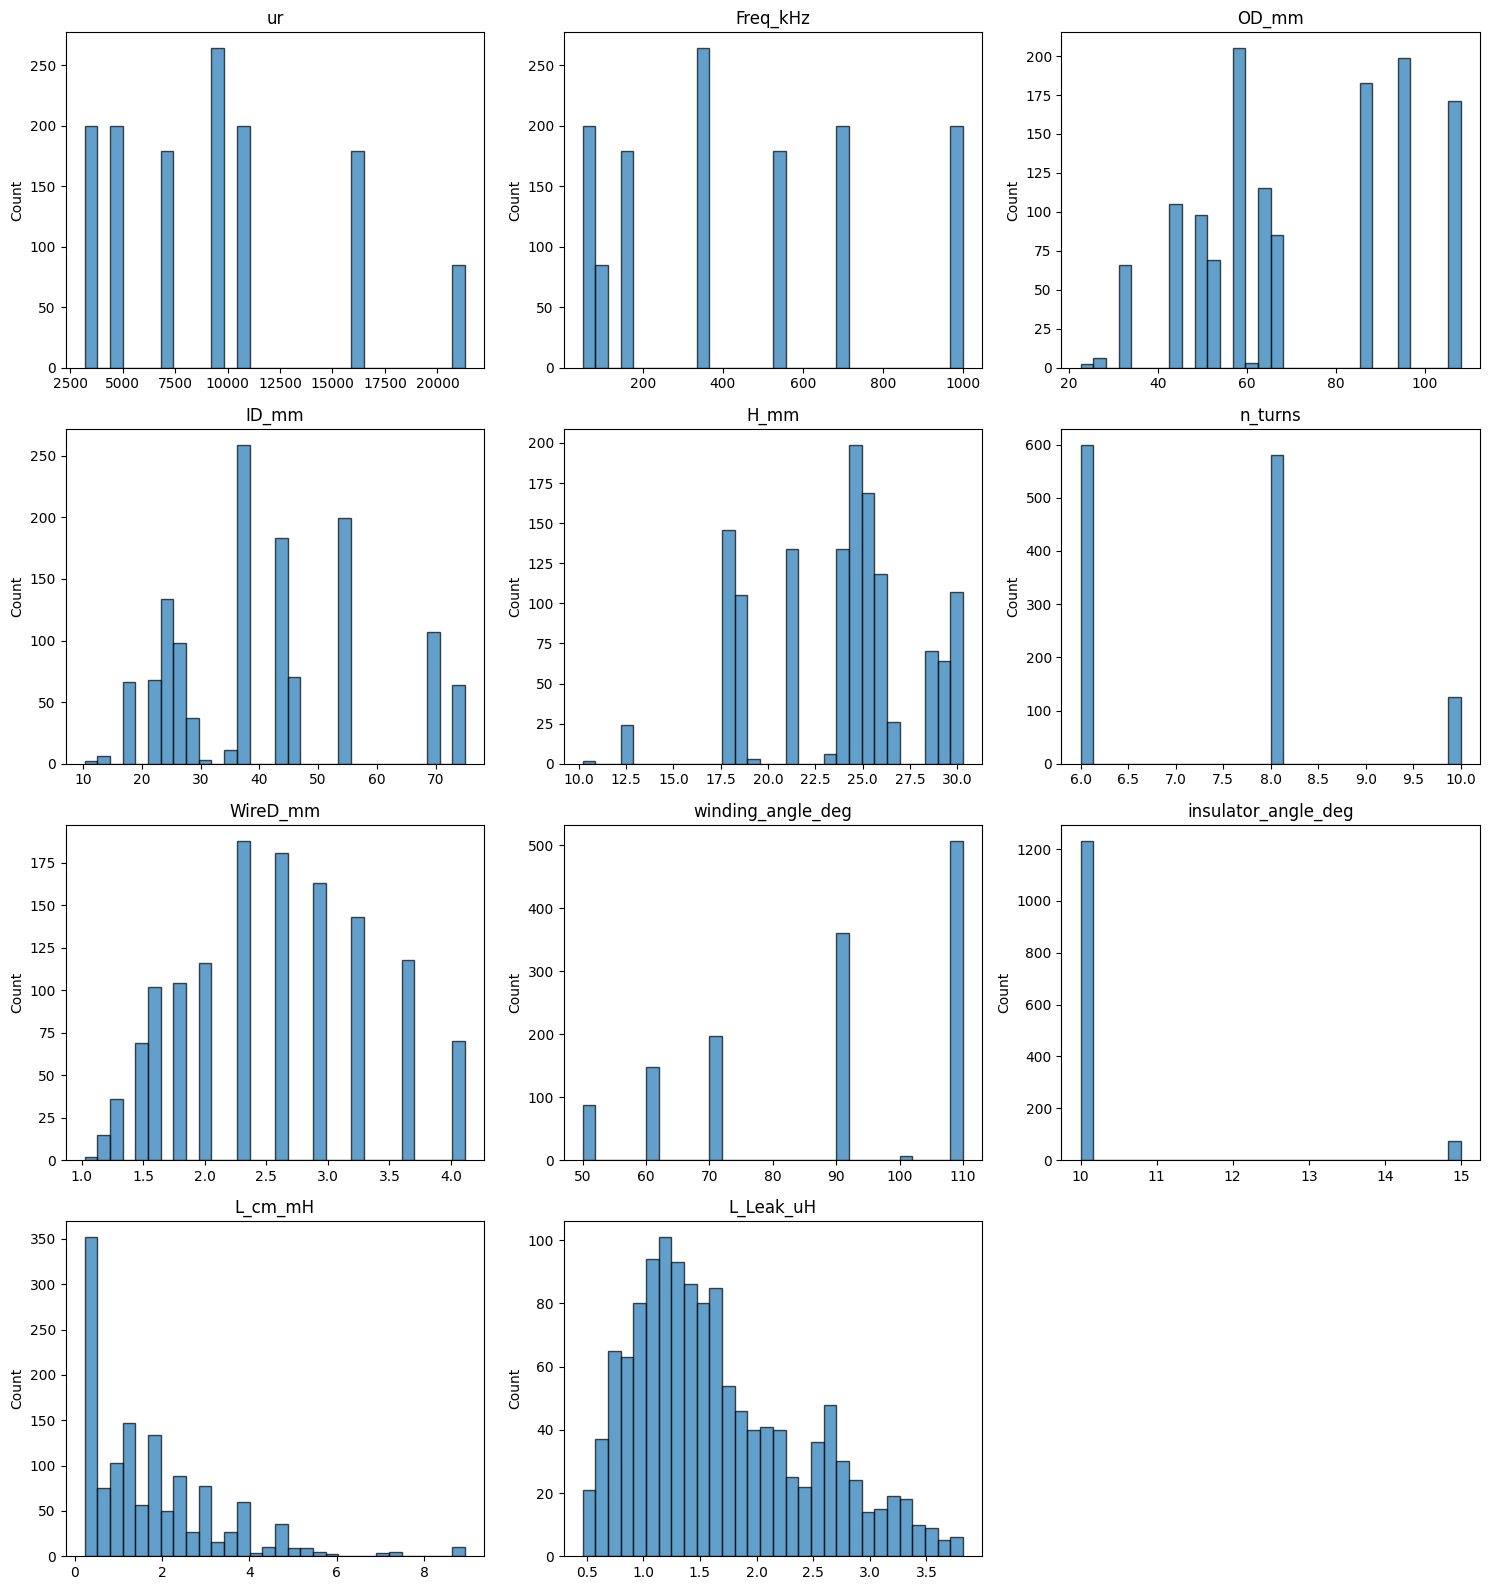

In [23]:
numeric_cols = df.select_dtypes(include="number").columns
n = len(numeric_cols)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, edgecolor="black", alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")

for i in range(n, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

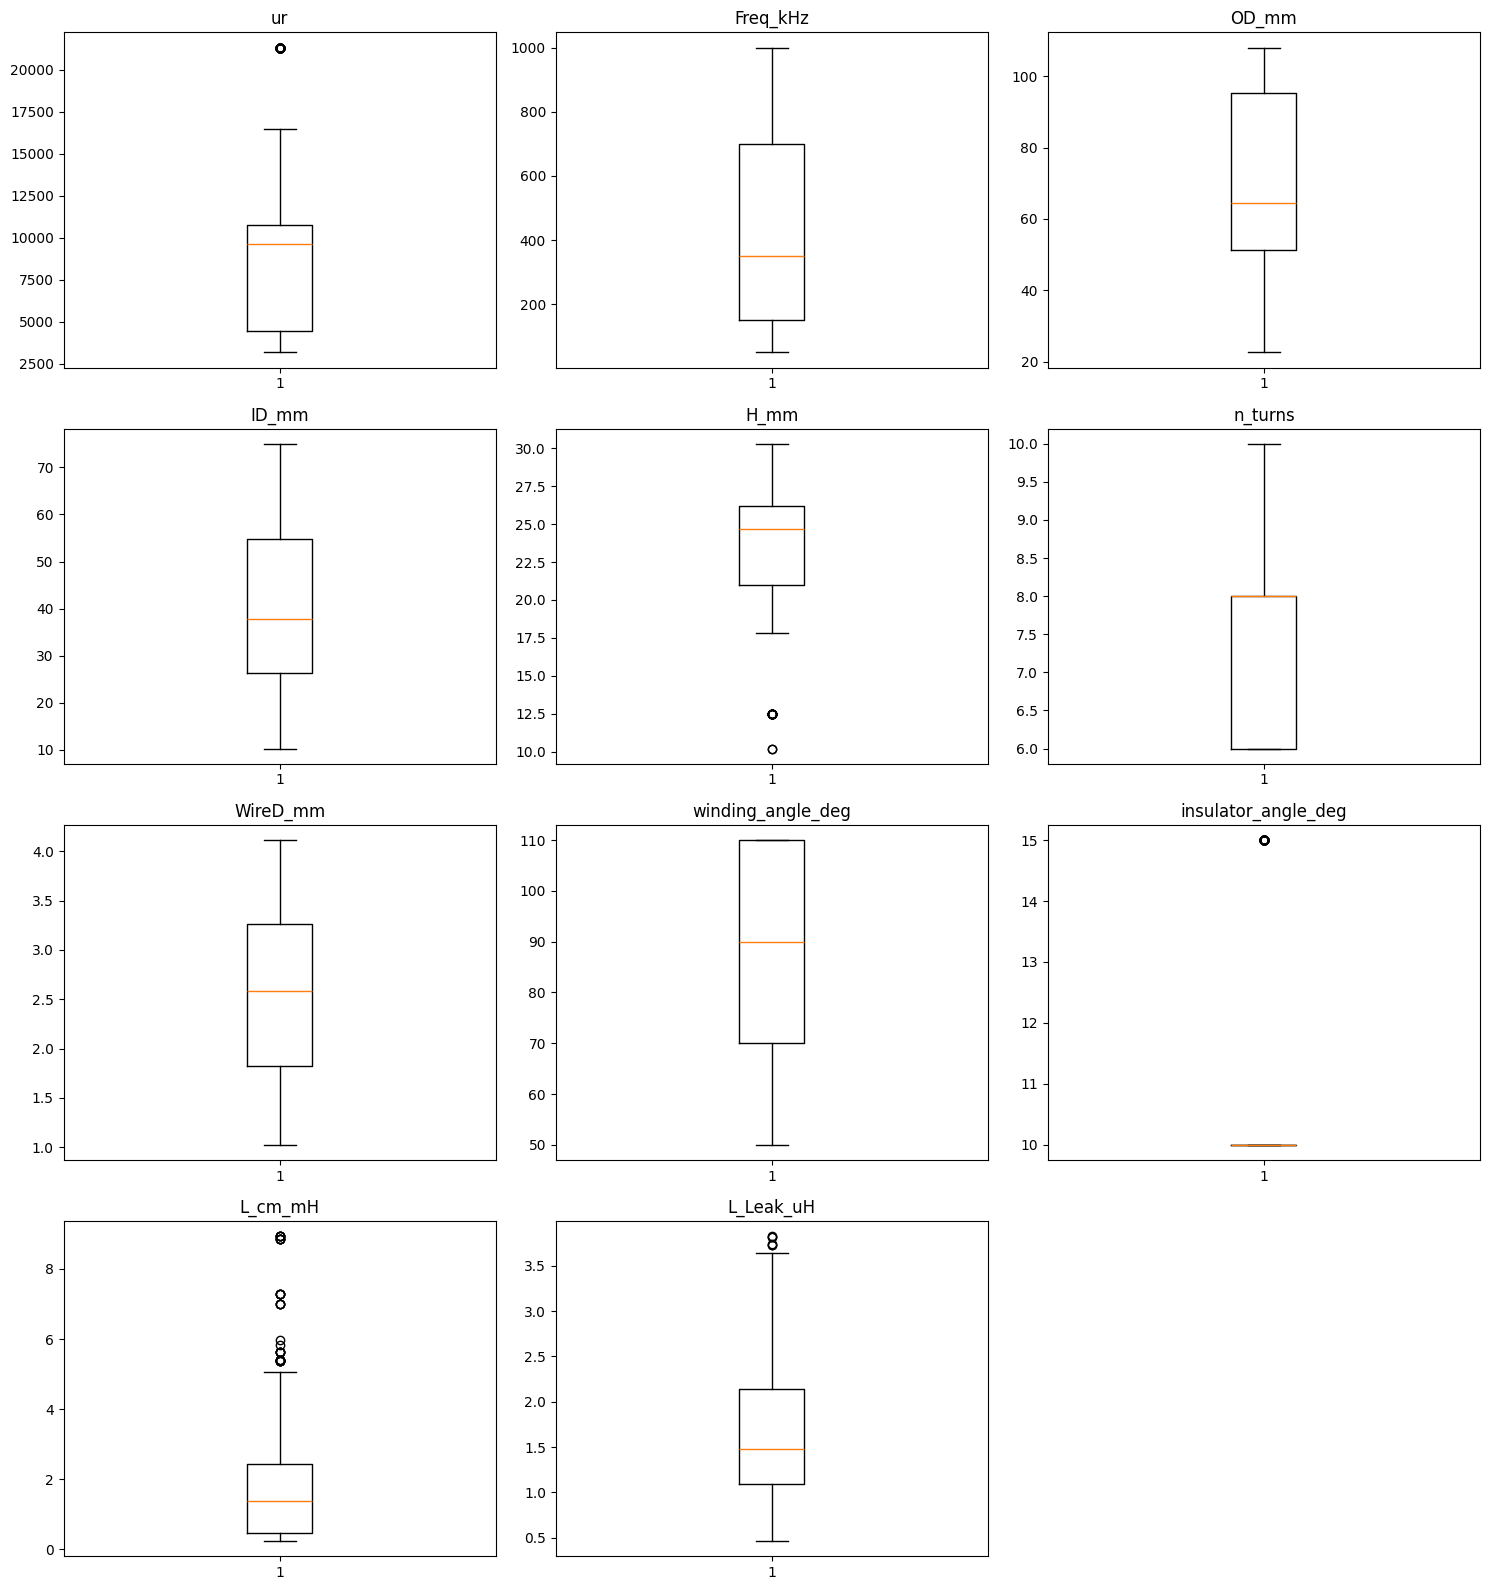

In [24]:
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col)

for i in range(n, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

## Correlation analysis

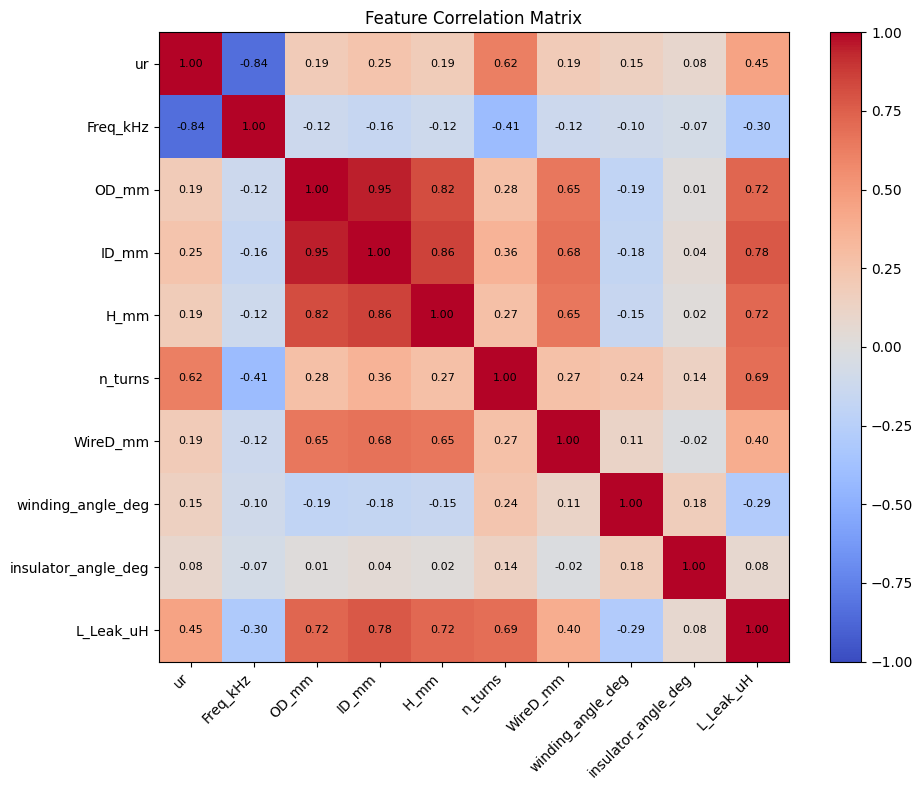

In [25]:
feature_cols = ["ur", "Freq_kHz", "OD_mm", "ID_mm", "H_mm", "n_turns", "WireD_mm", "winding_angle_deg", "insulator_angle_deg"]
target = "L_Leak_uH"

corr = df[feature_cols + [target]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [26]:
# Correlation of each feature with the target
corr[target].drop(target).sort_values(ascending=False)

ID_mm                  0.780959
OD_mm                  0.719777
H_mm                   0.717493
n_turns                0.692895
ur                     0.448147
WireD_mm               0.395161
insulator_angle_deg    0.077488
winding_angle_deg     -0.285219
Freq_kHz              -0.298243
Name: L_Leak_uH, dtype: float64

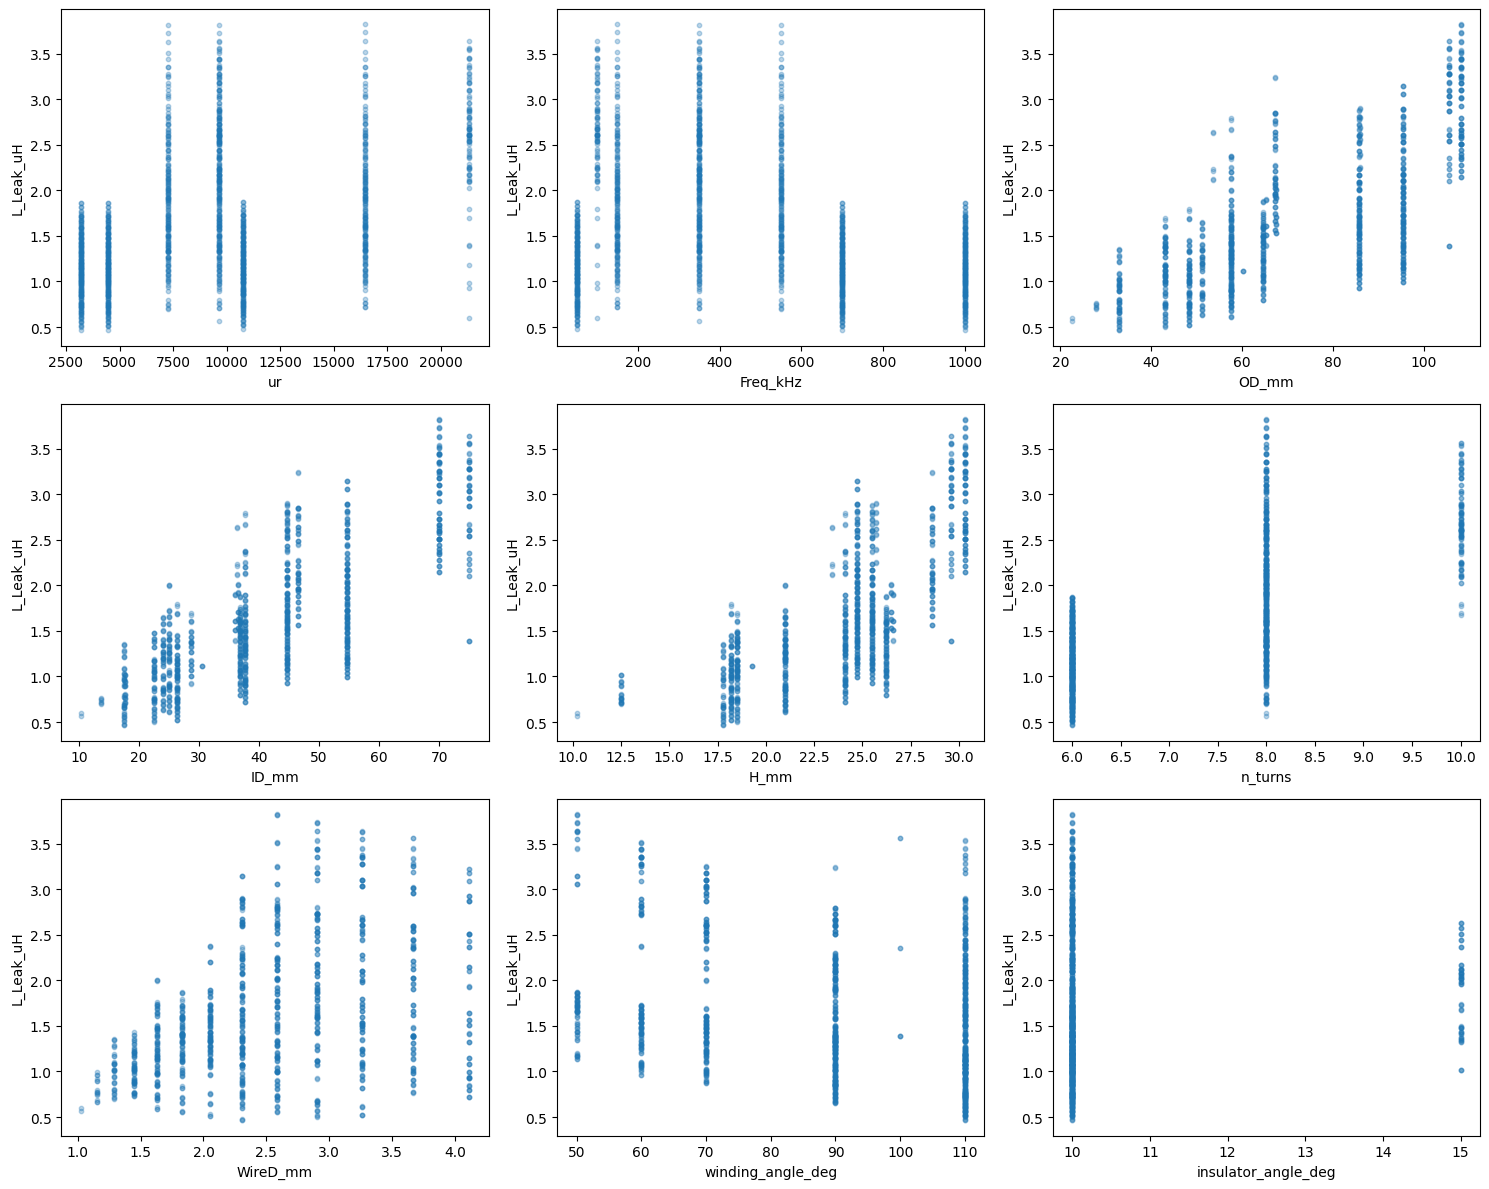

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].scatter(df[col], df[target], alpha=0.3, s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

plt.tight_layout()
plt.show()

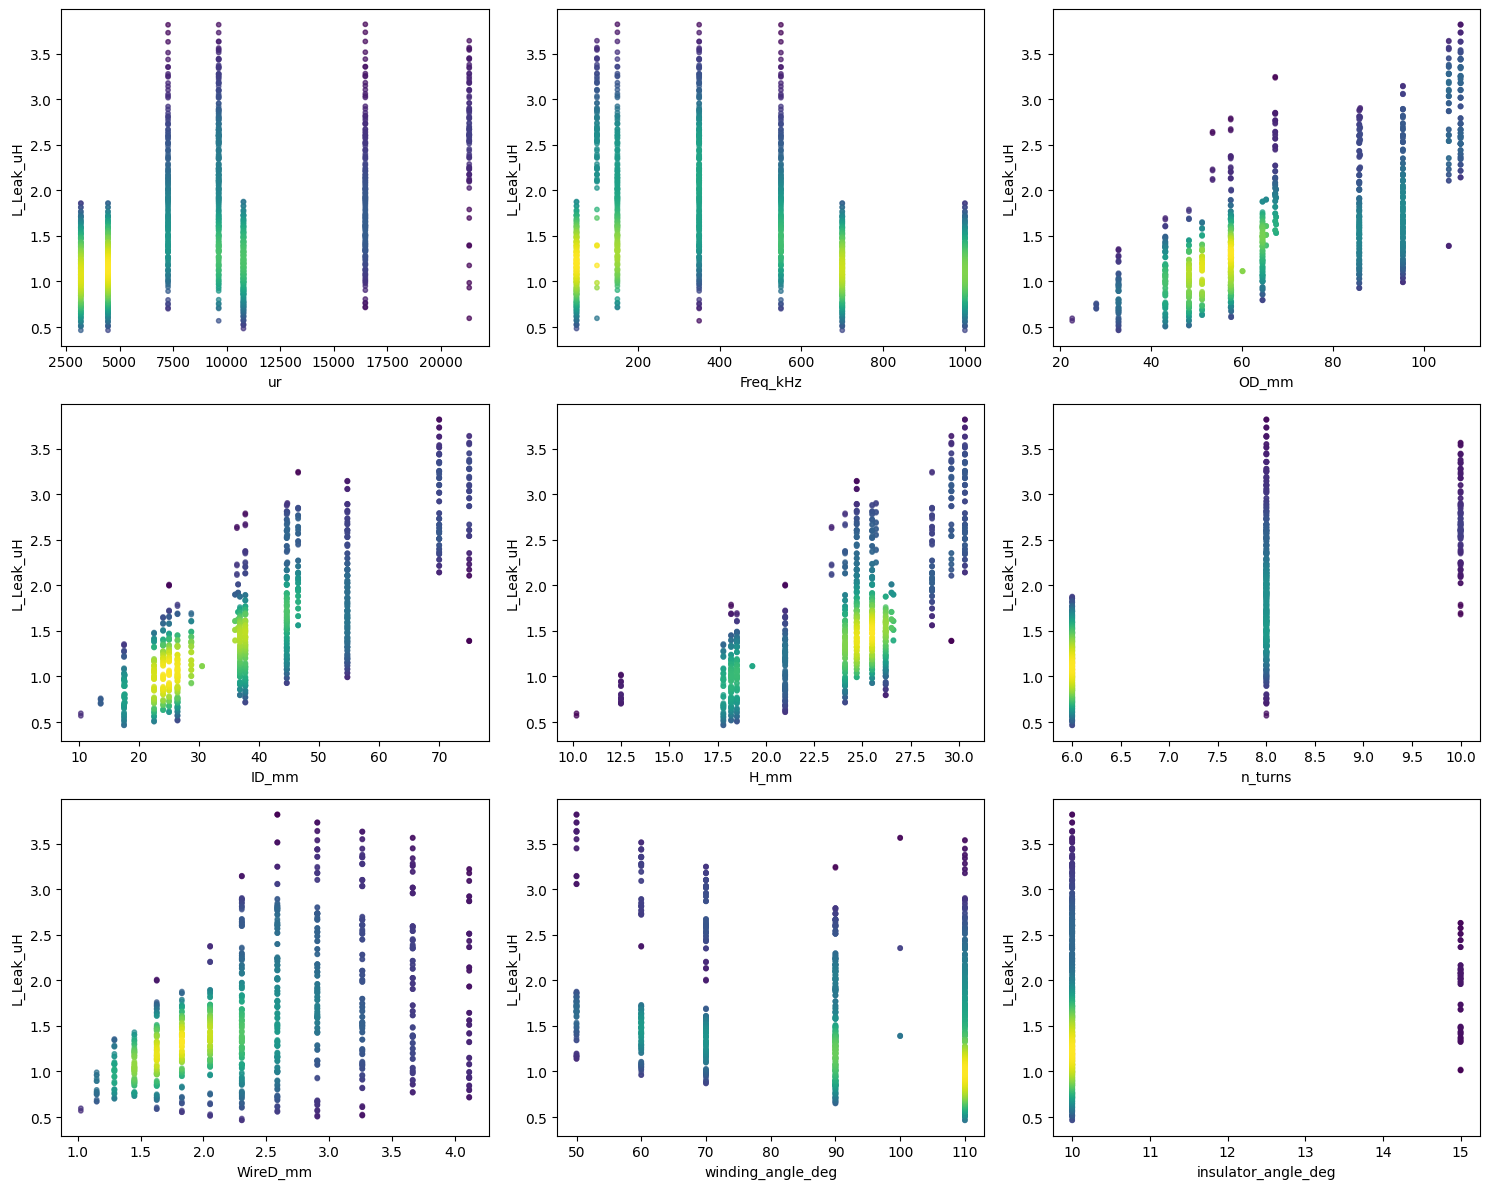

In [28]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    mask = df[[col, target]].dropna().index
    x = df.loc[mask, col].values
    y = df.loc[mask, target].values
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    density = kde(xy)

    idx = density.argsort()
    axes[i].scatter(x[idx], y[idx], c=density[idx], cmap="viridis", s=10, alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

plt.tight_layout()
plt.show()

## Feature selection

From the EDA above, `insulator_angle_deg` and `Freq_kHz` show weak correlation with the target (`L_Leak_uH`) and are not expected to be useful predictive features. The insulator angle is nearly constant across all configurations, and the frequency is already captured indirectly through the interpolated permeability (`ur`). Both columns are dropped going forward.

In [29]:
df = df.drop(columns=["insulator_angle_deg", "Freq_kHz"])
feature_cols = [c for c in feature_cols if c not in ["insulator_angle_deg", "Freq_kHz"]]

print(f"Remaining features: {feature_cols}")
print(df.shape)
df.head(5)

Remaining features: ['ur', 'OD_mm', 'ID_mm', 'H_mm', 'n_turns', 'WireD_mm', 'winding_angle_deg']
(1307, 11)


,cmc_id,material,ur,OD_mm,ID_mm,H_mm,n_turns,WireD_mm,winding_angle_deg,L_cm_mH,L_Leak_uH
0,VP500F_8_12.5_13.6_27.9_1.15_110_10_150.0,VP500F,16470.889463,27.9,13.6,12.5,8,1.150,110,2.586788,0.760568
1,VP500F_8_12.5_13.6_27.9_1.15_110_10_350.0,VP500F,9627.496534,27.9,13.6,12.5,8,1.150,110,1.585349,0.750023
2,VP500F_8_12.5_13.6_27.9_1.15_110_10_550.0,VP500F,7264.914526,27.9,13.6,12.5,8,1.150,110,1.228317,0.746770
3,VP500F_8_12.5_13.6_27.9_1.291_110_10_150.0,VP500F,16470.889463,27.9,13.6,12.5,8,1.291,110,2.586793,0.714369
4,VP500F_8_12.5_13.6_27.9_1.291_110_10_350.0,VP500F,9627.496534,27.9,13.6,12.5,8,1.291,110,1.585351,0.703529


In [30]:
df.to_pickle("data/df_clean.pkl")

# Train-Test Split

In [31]:
RANDOM_STATE = 42

# Stratified split based on binned target
df_split = df.dropna(subset=["L_Leak_uH"]).copy()
df_split["target_bin"] = pd.qcut(
    df_split["L_Leak_uH"], q=10, labels=False, duplicates="drop"
)

In [32]:
train_val, test = train_test_split(
    df_split, test_size=0.2,
    random_state=RANDOM_STATE, stratify=df_split["target_bin"],
)

train_val = train_val.drop(columns="target_bin")
test = test.drop(columns="target_bin")

print(
    f"Train+Val: {train_val.shape[0]} rows"
    f" ({train_val.shape[0] / len(df_split) * 100:.0f}%)"
)
print(
    f"Test:      {test.shape[0]} rows"
    f" ({test.shape[0] / len(df_split) * 100:.0f}%)"
)

Train+Val: 1045 rows (80%)
Test:      262 rows (20%)


In [33]:
train_val.to_pickle("data/train_val.pkl")
test.to_pickle("data/test.pkl")

# Training set EDA

In [34]:
train_val = pd.read_pickle("data/train_val.pkl")

feature_cols = [
    "ur", "OD_mm", "ID_mm", "H_mm", "n_turns", "WireD_mm", "winding_angle_deg"
]
target = "L_Leak_uH"

print(train_val.shape)
train_val.head(5)

(1045, 11)


,cmc_id,material,ur,OD_mm,ID_mm,H_mm,n_turns,WireD_mm,winding_angle_deg,L_cm_mH,L_Leak_uH
581,VP500F_10_18.2_26.4_48.3_1.828_110_10_100.0,VP500F,21319.876850,48.3,26.4,18.2,10,1.828,110,5.839669,1.790295
1105,T38_6_24.7_54.7_95.4_3.264_110_10_1000.0,T38,3194.456552,95.4,54.7,24.7,6,3.264,110,0.316049,1.078818
417,VP500F_8_28.6_46.5_67.3_2.305_110_10_150.0,VP500F,16470.889463,67.3,46.5,28.6,8,2.305,110,3.045146,1.940940
935,T38_6_24.1_37.7_57.5_1.828_50_10_50.0,T38,10783.562940,57.5,37.7,24.1,6,1.828,50,0.790094,1.538569
964,T38_6_24.1_37.7_57.5_2.305_70_10_1000.0,T38,3194.456552,57.5,37.7,24.1,6,2.305,70,0.234110,1.239544


In [35]:
train_val.describe()

,ur,OD_mm,ID_mm,H_mm,n_turns,WireD_mm,winding_angle_deg,L_cm_mH,L_Leak_uH
count,1045.000000,1045.000000,1045.000000,1045.000000,1045.000000,1045.000000,1045.000000,1045.000000,1045.000000
mean,9477.190754,71.679234,41.806220,23.936842,7.261244,2.537824,88.660287,1.784635,1.662801
std,5240.392439,23.082609,16.128015,4.090058,1.309295,0.768947,20.620741,1.546856,0.749073
min,3194.456552,22.600000,10.300000,10.200000,6.000000,1.024000,50.000000,0.234020,0.464241
25%,4461.991276,51.200000,26.400000,21.000000,6.000000,1.828000,70.000000,0.472489,1.098699
50%,9627.496534,65.300000,37.700000,24.700000,8.000000,2.588000,90.000000,1.360931,1.482410
75%,10783.562940,95.400000,54.700000,26.200000,8.000000,3.264000,110.000000,2.425025,2.130019
max,21319.876850,108.100000,75.000000,30.300000,10.000000,4.115000,110.000000,8.932931,3.823521


## Feature distributions

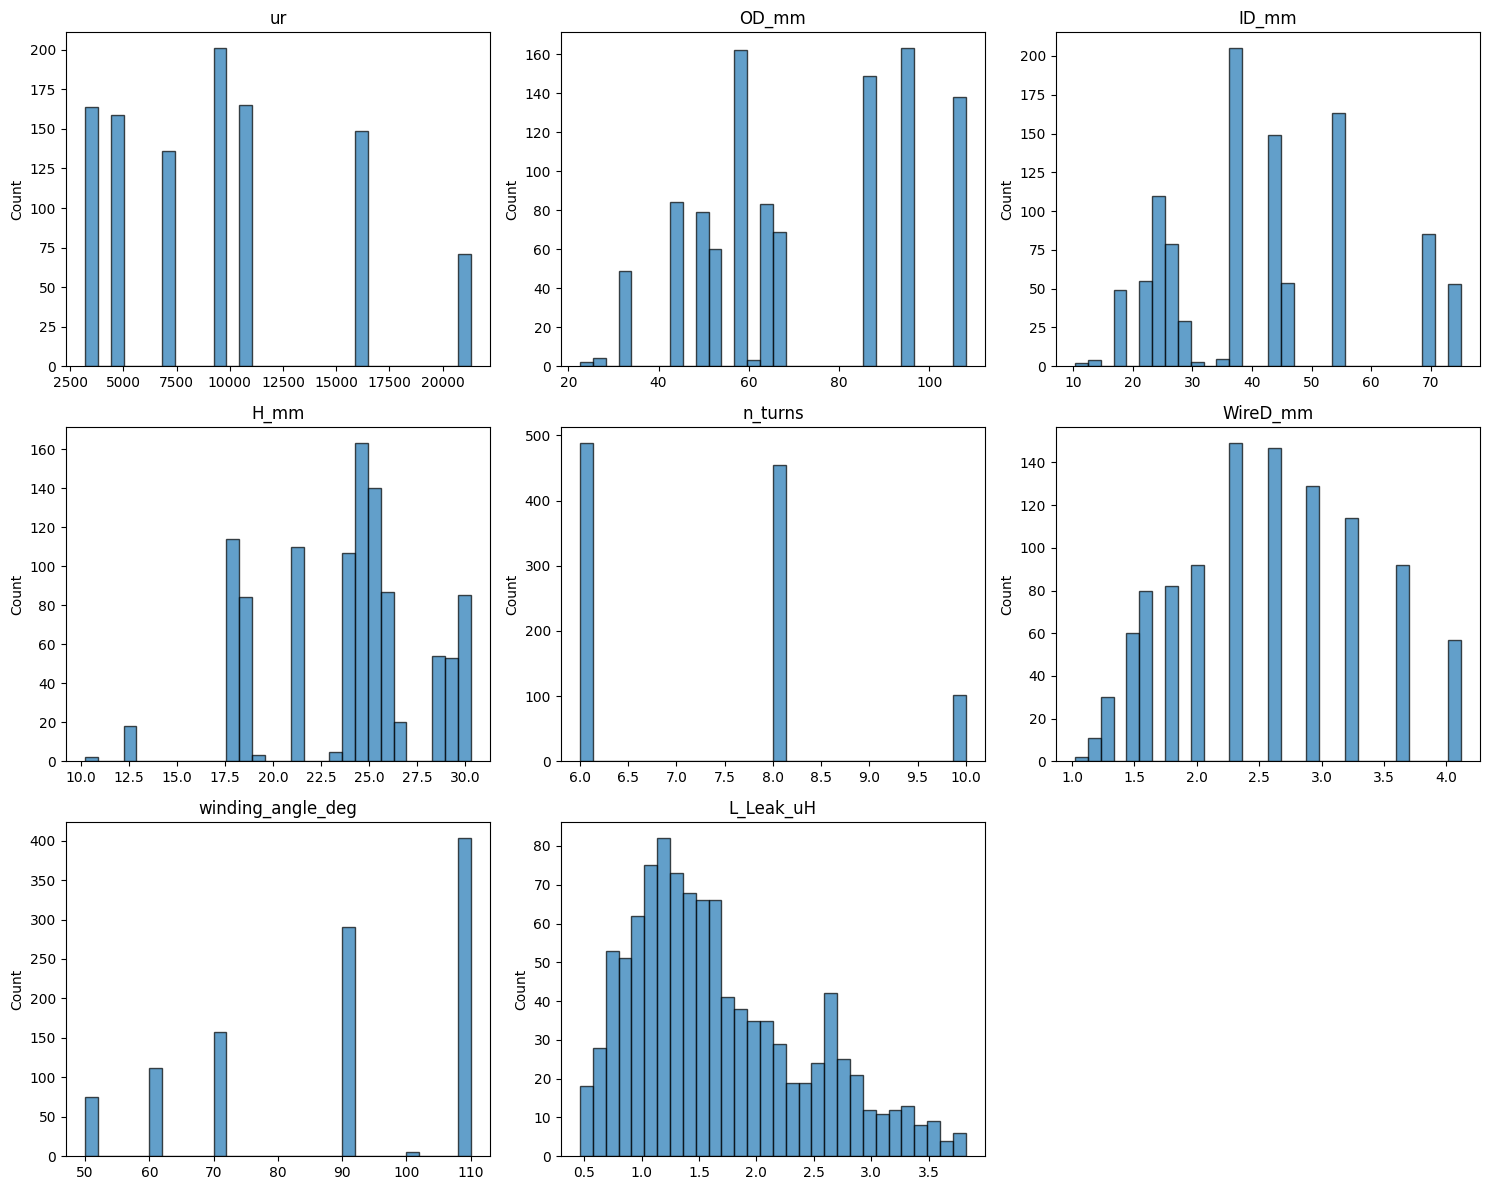

In [36]:
numeric_cols = train_val[feature_cols + [target]].columns
n = len(numeric_cols)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(train_val[col], bins=30, edgecolor="black", alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")

for i in range(n, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

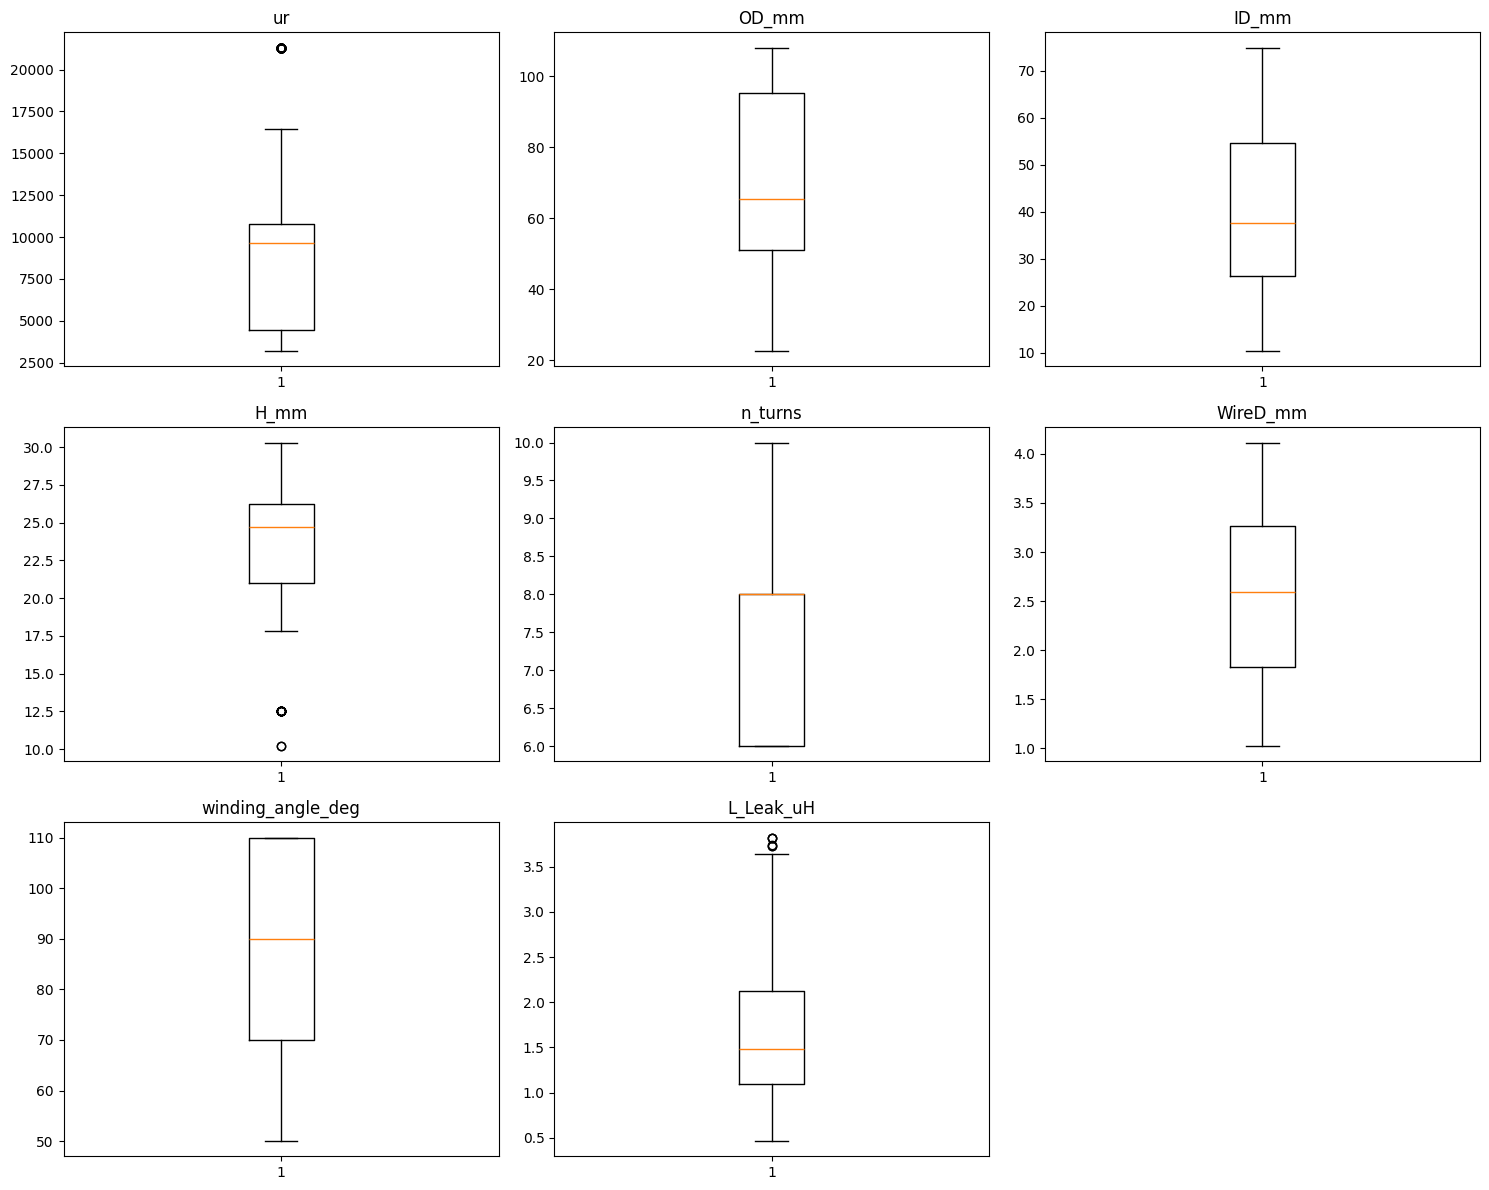

In [37]:
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(train_val[col].dropna(), vert=True)
    axes[i].set_title(col)

for i in range(n, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

## Correlation analysis

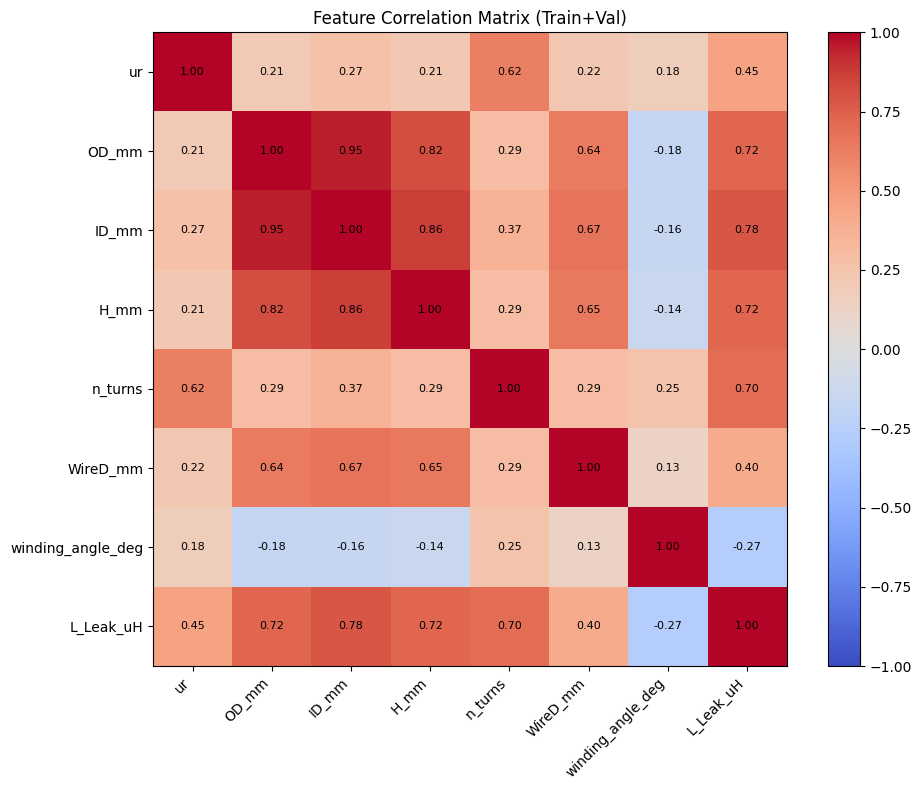

In [38]:
corr = train_val[feature_cols + [target]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(
            j, i, f"{corr.iloc[i, j]:.2f}",
            ha="center", va="center", fontsize=8,
        )

plt.colorbar(im)
plt.title("Feature Correlation Matrix (Train+Val)")
plt.tight_layout()
plt.show()

In [39]:
# Correlation of each feature with the target
corr[target].drop(target).sort_values(ascending=False)

ID_mm                0.782091
H_mm                 0.721511
OD_mm                0.720919
n_turns              0.698263
ur                   0.451056
WireD_mm             0.398522
winding_angle_deg   -0.268431
Name: L_Leak_uH, dtype: float64

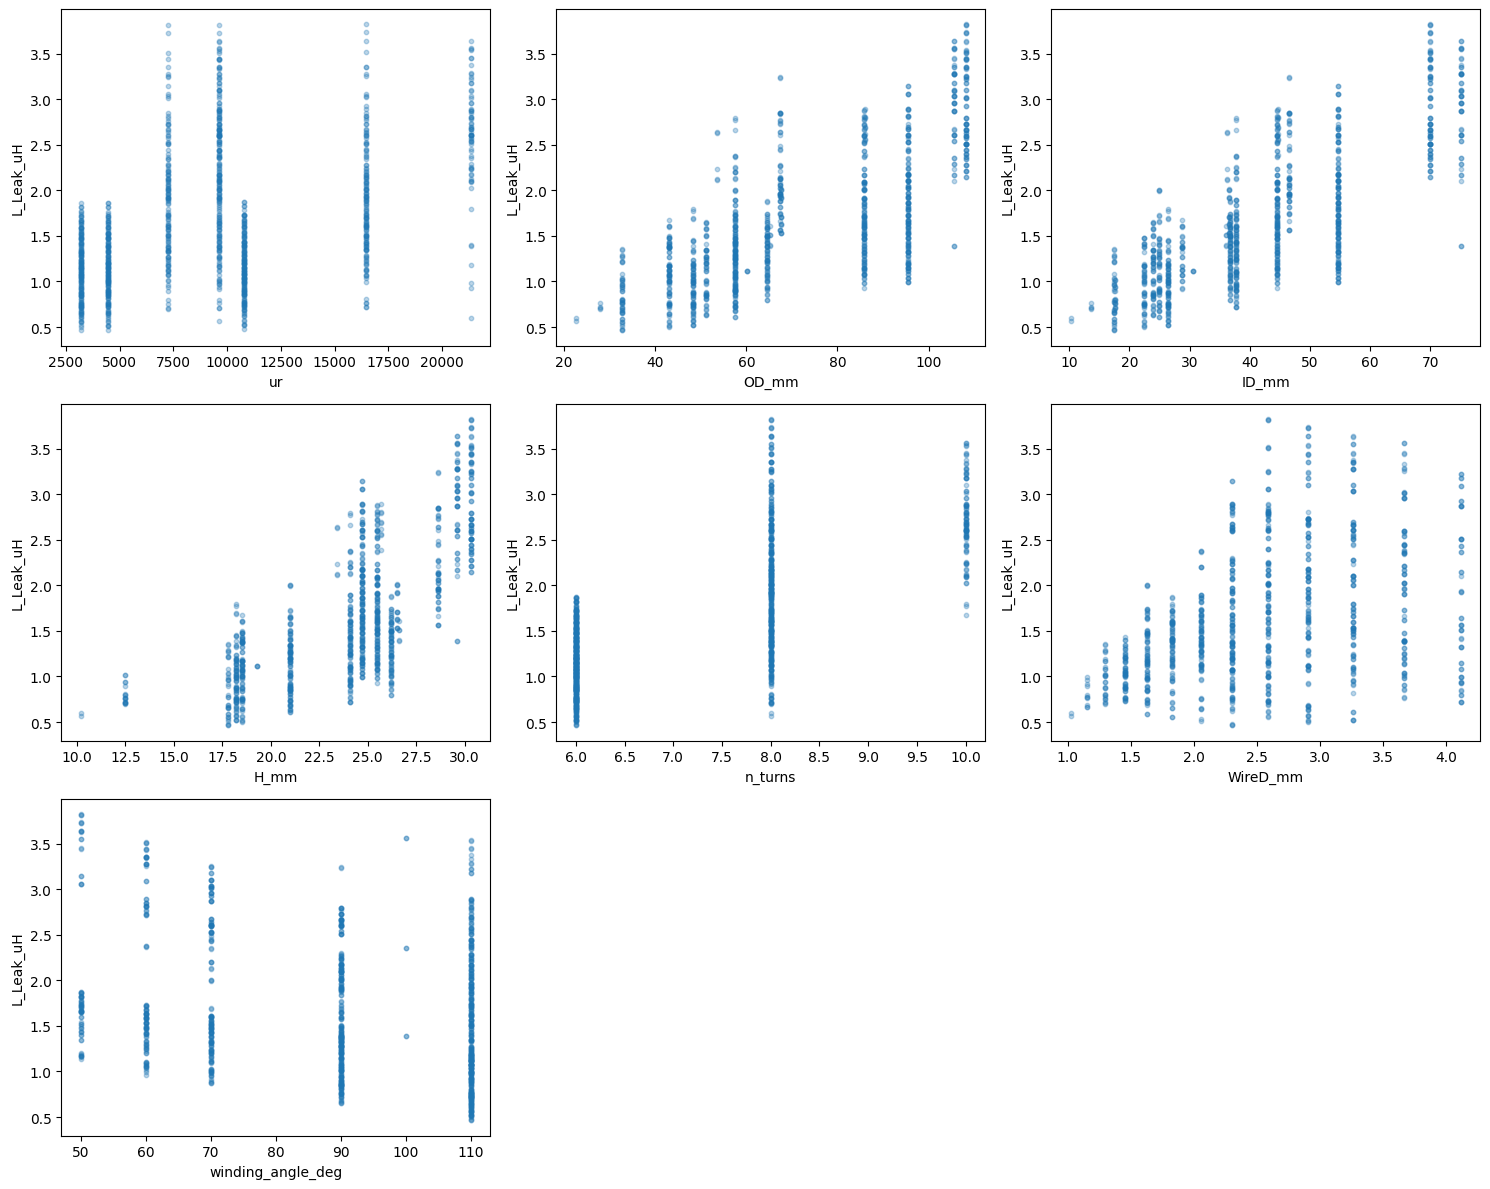

In [40]:
n_features = len(feature_cols)
cols = 3
rows = (n_features + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].scatter(train_val[col], train_val[target], alpha=0.3, s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

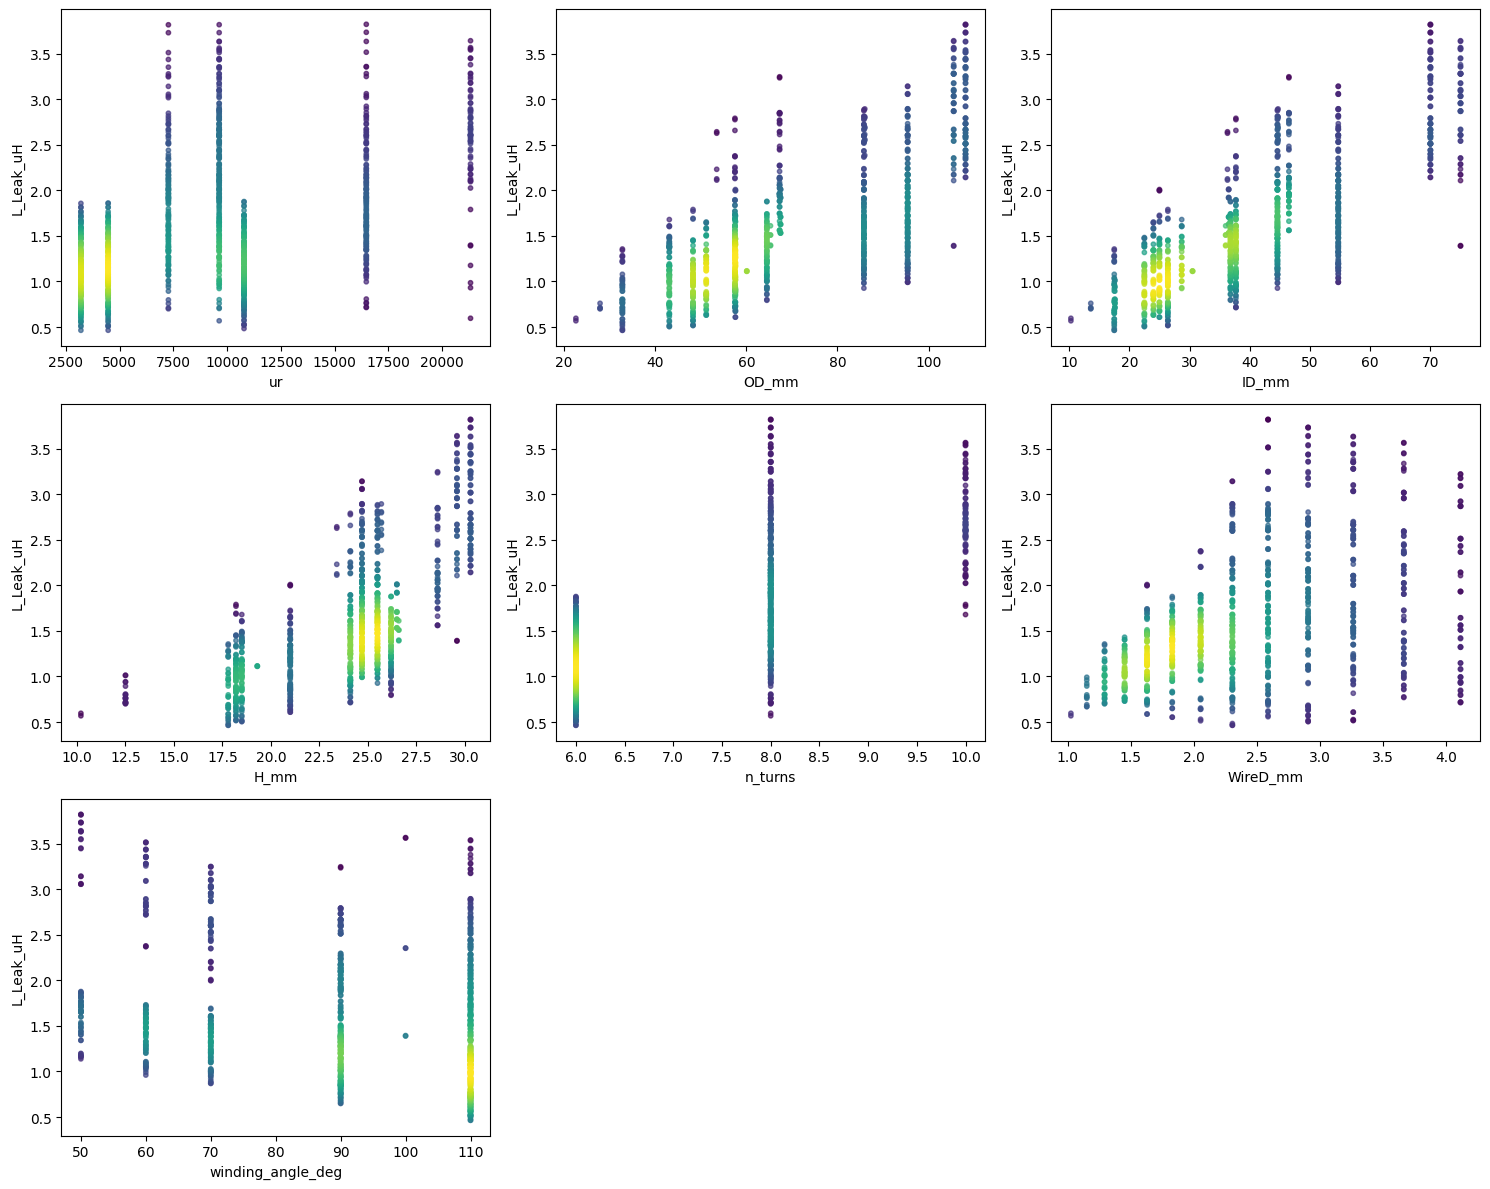

In [41]:
fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    mask = train_val[[col, target]].dropna().index
    x = train_val.loc[mask, col].values
    y_vals = train_val.loc[mask, target].values
    xy = np.vstack([x, y_vals])
    kde = gaussian_kde(xy)
    density = kde(xy)

    idx = density.argsort()
    axes[i].scatter(
        x[idx], y_vals[idx], c=density[idx], cmap="viridis", s=10, alpha=0.7
    )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# Linear Regression Model

In [42]:
RANDOM_STATE = 42
K = 5

feature_cols = [
    "ur", "OD_mm", "ID_mm", "H_mm", "n_turns", "WireD_mm", "winding_angle_deg"
]
target = "L_Leak_uH"

train_val = pd.read_pickle("data/train_val.pkl")
train_val = train_val.dropna(subset=feature_cols + [target])

X = train_val[feature_cols].copy()
y = train_val[target].copy()

print(f"X: {X.shape}, y: {y.shape}")

X: (1045, 7), y: (1045,)


In [43]:
# Define feature transformations
transformations = {
    "none": lambda x: x,
    "log": lambda x: np.log1p(x),
    "sqrt": lambda x: np.sqrt(x),
    "squared": lambda x: x ** 2,
}

# Scoring metrics
scoring = {
    "MSE": "neg_mean_squared_error",
    "R2": "r2",
}

kf = KFold(n_splits=K, shuffle=True, random_state=RANDOM_STATE)

In [44]:
def evaluate_combo(X, y, combo):
    """Apply a transformation combo to X and run K-fold CV with LinearRegression."""
    X_transformed = X.copy()
    for col, t_name in zip(feature_cols, combo):
        X_transformed[col] = transformations[t_name](X_transformed[col])

    # Skip combos that produce non-finite values
    if not np.isfinite(X_transformed.values).all():
        return None

    model = LinearRegression()
    cv_results = cross_validate(
        model, X_transformed, y, cv=kf,
        scoring=scoring, return_train_score=True,
    )

    if np.isnan(cv_results["test_MSE"]).any():
        return None

    # Fit on full data for coefficients
    model.fit(X_transformed, y)
    if not np.isfinite(model.coef_).all():
        return None

    result = {
        "train_MSE": -cv_results["train_MSE"].mean(),
        "val_MSE": -cv_results["test_MSE"].mean(),
        "train_R2": cv_results["train_R2"].mean(),
        "val_R2": cv_results["test_R2"].mean(),
        "intercept": model.intercept_,
    }
    for col, coef in zip(feature_cols, model.coef_):
        result[f"coef_{col}"] = coef

    return result

## Vanilla baseline (no transformations)

In [45]:
model_baseline = LinearRegression()
cv_baseline = cross_validate(
    model_baseline, X, y, cv=kf, scoring=scoring, return_train_score=True
)
model_baseline.fit(X, y)

print("Vanilla Linear Regression (5-fold CV):")
print(
    f"  Train MSE:  {-cv_baseline['train_MSE'].mean():.6f}"
    f" (+/- {cv_baseline['train_MSE'].std():.6f})"
)
print(
    f"  Val   MSE:  {-cv_baseline['test_MSE'].mean():.6f}"
    f" (+/- {cv_baseline['test_MSE'].std():.6f})"
)
print(f"  Train R2:   {cv_baseline['train_R2'].mean():.4f}")
print(f"  Val   R2:   {cv_baseline['test_R2'].mean():.4f}")

print(f"\nCoefficients:")
for col, coef in zip(feature_cols, model_baseline.coef_):
    print(f"  {col:>20s}: {coef:.6f}")
print(f"  {'intercept':>20s}: {model_baseline.intercept_:.6f}")

Vanilla Linear Regression (5-fold CV):
  Train MSE:  0.035024 (+/- 0.001631)
  Val   MSE:  0.035503 (+/- 0.006599)
  Train R2:   0.9375
  Val   R2:   0.9369

Coefficients:
                    ur: 0.000001
                 OD_mm: 0.002908
                 ID_mm: 0.013642
                  H_mm: 0.056114
               n_turns: 0.342249
              WireD_mm: -0.190836
     winding_angle_deg: -0.010512
             intercept: -1.542247


## StandardScaler test

Test whether standardizing the features improves the linear regression. For OLS,
scaling is a linear transformation so predictions should be mathematically
identical — but it can help with numerical conditioning.

In [46]:
pipe_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression()),
])

cv_scaled = cross_validate(
    pipe_scaled, X, y, cv=kf, scoring=scoring, return_train_score=True
)
pipe_scaled.fit(X, y)
lr_scaled = pipe_scaled.named_steps["lr"]

print("Linear Regression + StandardScaler (5-fold CV):")
print(
    f"  Train MSE:  {-cv_scaled['train_MSE'].mean():.6f}"
    f" (+/- {cv_scaled['train_MSE'].std():.6f})"
)
print(
    f"  Val   MSE:  {-cv_scaled['test_MSE'].mean():.6f}"
    f" (+/- {cv_scaled['test_MSE'].std():.6f})"
)
print(f"  Train R2:   {cv_scaled['train_R2'].mean():.4f}")
print(f"  Val   R2:   {cv_scaled['test_R2'].mean():.4f}")

print(f"\nCoefficients (in scaled space):")
for col, coef in zip(feature_cols, lr_scaled.coef_):
    print(f"  {col:>20s}: {coef:.6f}")
print(f"  {'intercept':>20s}: {lr_scaled.intercept_:.6f}")

Linear Regression + StandardScaler (5-fold CV):
  Train MSE:  0.035024 (+/- 0.001631)
  Val   MSE:  0.035503 (+/- 0.006599)
  Train R2:   0.9375
  Val   R2:   0.9369

Coefficients (in scaled space):
                    ur: 0.007845
                 OD_mm: 0.067100
                 ID_mm: 0.219914
                  H_mm: 0.229400
               n_turns: 0.447891
              WireD_mm: -0.146672
     winding_angle_deg: -0.216659
             intercept: 1.662801


## Target transformations

Test an alternative target formulation with vanilla features (no feature
transforms):
- **Log target**: `y = log(L_Leak_uH)` — makes the model minimize relative errors

In [47]:
y_log = np.log(y)

model_log = LinearRegression()
cv_log = cross_validate(
    model_log, X, y_log, cv=kf, scoring=scoring, return_train_score=True
)
model_log.fit(X, y_log)

print("Log target — Linear Regression (5-fold CV):")
print(f"  Train MSE:  {-cv_log['train_MSE'].mean():.6f}")
print(f"  Val   MSE:  {-cv_log['test_MSE'].mean():.6f}")
print(f"  Train R2:   {cv_log['train_R2'].mean():.4f}")
print(f"  Val   R2:   {cv_log['test_R2'].mean():.4f}")

print(f"\nCoefficients:")
for col, coef in zip(feature_cols, model_log.coef_):
    print(f"  {col:>20s}: {coef:.6f}")
print(f"  {'intercept':>20s}: {model_log.intercept_:.6f}")

Log target — Linear Regression (5-fold CV):
  Train MSE:  0.009207
  Val   MSE:  0.009399
  Train R2:   0.9554
  Val   R2:   0.9546

Coefficients:
                    ur: 0.000002
                 OD_mm: 0.005469
                 ID_mm: 0.000061
                  H_mm: 0.048473
               n_turns: 0.210075
              WireD_mm: -0.132376
     winding_angle_deg: -0.006814
             intercept: -1.749318


## Feature transformation search

Testing all combinations of {none, log, sqrt, squared} across the 7 features
(4^7 = 16,384 combinations) for each target formulation.

In [48]:
transform_names = list(transformations.keys())
all_combos = list(product(transform_names, repeat=len(feature_cols)))
print(f"Total combinations per target: {len(all_combos)}")

Total combinations per target: 16384


In [49]:
# --- Original target ---
print("--- Original target (L_Leak_uH) ---")
results_orig = []
for i, combo in enumerate(all_combos):
    metrics = evaluate_combo(X, y, combo)
    if metrics is None:
        continue
    row = {col: t for col, t in zip(feature_cols, combo)}
    row.update(metrics)
    results_orig.append(row)
    if (i + 1) % 4000 == 0:
        print(f"  {i + 1}/{len(all_combos)} done...")
print(f"Evaluated: {len(results_orig)}")

--- Original target (L_Leak_uH) ---
  4000/16384 done...
  8000/16384 done...
  12000/16384 done...
  16000/16384 done...
Evaluated: 16384


In [50]:
# --- Log target ---
print("--- Log target: log(L_Leak_uH) ---")
results_log = []
for i, combo in enumerate(all_combos):
    metrics = evaluate_combo(X, y_log, combo)
    if metrics is None:
        continue
    row = {col: t for col, t in zip(feature_cols, combo)}
    row.update(metrics)
    results_log.append(row)
    if (i + 1) % 4000 == 0:
        print(f"  {i + 1}/{len(all_combos)} done...")
print(f"Evaluated: {len(results_log)}")

--- Log target: log(L_Leak_uH) ---
  4000/16384 done...
  8000/16384 done...
  12000/16384 done...
  16000/16384 done...
Evaluated: 16384


In [51]:
metric_cols = ["train_MSE", "val_MSE", "train_R2", "val_R2"]
coef_cols = ["intercept"] + [f"coef_{c}" for c in feature_cols]

df_results_orig = (
    pd.DataFrame(results_orig).sort_values("val_MSE").reset_index(drop=True)
)
df_results_log = (
    pd.DataFrame(results_log).sort_values("val_MSE").reset_index(drop=True)
)

print("Top 10 — Original target (L_Leak_uH):")
display(df_results_orig[feature_cols + metric_cols + coef_cols].head(10))

print("\nTop 10 — Log target (log(L_Leak_uH)):")
display(df_results_log[feature_cols + metric_cols + coef_cols].head(10))

Top 10 — Original target (L_Leak_uH):


,ur,OD_mm,ID_mm,H_mm,n_turns,WireD_mm,winding_angle_deg,train_MSE,val_MSE,train_R2,val_R2,intercept,coef_ur,coef_OD_mm,coef_ID_mm,coef_H_mm,coef_n_turns,coef_WireD_mm,coef_winding_angle_deg
0,log,squared,squared,none,log,squared,log,0.030117,0.030602,0.946276,0.945425,-2.157672,9.361343e-03,0.000030,0.000101,0.062219,2.911095,-0.031231,-0.900007
1,sqrt,squared,squared,none,log,squared,log,0.030128,0.030621,0.946258,0.945394,-2.105271,1.212913e-04,0.000030,0.000102,0.062210,2.920343,-0.031231,-0.899740
2,none,squared,squared,none,log,squared,log,0.030132,0.030637,0.946250,0.945367,-2.116934,1.443866e-07,0.000030,0.000102,0.062199,2.930105,-0.031225,-0.899454
3,squared,squared,squared,none,log,squared,log,0.030121,0.030654,0.946269,0.945341,-2.145692,-2.927581e-11,0.000030,0.000103,0.062173,2.945319,-0.031198,-0.899056
4,log,squared,squared,sqrt,log,squared,log,0.030177,0.030656,0.946171,0.945347,-3.486767,9.360867e-03,0.000026,0.000119,0.567204,2.925352,-0.031465,-0.896574
5,sqrt,squared,squared,sqrt,log,squared,log,0.030188,0.030675,0.946151,0.945314,-3.434998,1.147990e-04,0.000026,0.000119,0.567103,2.935271,-0.031465,-0.896289
6,none,squared,squared,sqrt,log,squared,log,0.030192,0.030693,0.946144,0.945287,-3.447761,7.948249e-08,0.000026,0.000119,0.566999,2.945634,-0.031458,-0.895986
7,squared,squared,squared,sqrt,log,squared,log,0.030178,0.030710,0.946170,0.945261,-3.477886,-3.412088e-11,0.000026,0.000120,0.566798,2.961612,-0.031429,-0.895569
8,log,none,squared,none,log,squared,log,0.030231,0.030719,0.946074,0.945224,-2.223460,8.725594e-03,0.003739,0.000121,0.059048,2.911931,-0.031524,-0.897338
9,log,squared,squared,sqrt,log,none,log,0.030274,0.030722,0.945998,0.945240,-3.455249,9.373274e-03,0.000029,0.000110,0.595970,2.941271,-0.176728,-0.891501



Top 10 — Log target (log(L_Leak_uH)):


,ur,OD_mm,ID_mm,H_mm,n_turns,WireD_mm,winding_angle_deg,train_MSE,val_MSE,train_R2,val_R2,intercept,coef_ur,coef_OD_mm,coef_ID_mm,coef_H_mm,coef_n_turns,coef_WireD_mm,coef_winding_angle_deg
0,log,log,log,log,log,log,sqrt,0.005938,0.006040,0.971229,0.970750,-6.695441,2.111001e-02,0.266820,0.223047,0.905113,1.836474,-0.533166,-0.120869
1,log,log,log,log,log,log,log,0.005986,0.006089,0.970993,0.970503,-5.385060,2.070840e-02,0.264441,0.223719,0.906027,1.838766,-0.532010,-0.545901
2,sqrt,log,log,log,log,log,sqrt,0.005981,0.006090,0.971018,0.970512,-6.568082,3.278260e-04,0.266114,0.223939,0.904656,1.851825,-0.533252,-0.120776
3,log,log,log,log,log,log,none,0.005991,0.006095,0.970971,0.970497,-7.235192,2.145156e-02,0.269232,0.224041,0.904094,1.832259,-0.536523,-0.006662
4,log,log,log,log,log,sqrt,sqrt,0.005993,0.006099,0.970960,0.970465,-6.572359,2.127893e-02,0.265867,0.221302,0.897548,1.835872,-0.473948,-0.121235
5,none,log,log,log,log,log,sqrt,0.006012,0.006127,0.970868,0.970333,-6.581665,9.023607e-07,0.265540,0.224766,0.904380,1.868454,-0.533131,-0.120677
6,log,sqrt,log,log,log,log,sqrt,0.006023,0.006128,0.970815,0.970331,-6.180499,2.073345e-02,0.060605,0.219688,0.949630,1.825572,-0.529519,-0.120912
7,log,log,log,sqrt,log,log,sqrt,0.006029,0.006136,0.970789,0.970312,-5.594822,2.044449e-02,0.290312,0.194330,0.376992,1.821166,-0.528430,-0.121027
8,sqrt,log,log,log,log,log,log,0.006029,0.006137,0.970785,0.970269,-5.261567,3.180875e-04,0.263740,0.224606,0.905575,1.854204,-0.532083,-0.545495
9,sqrt,log,log,log,log,log,none,0.006035,0.006145,0.970758,0.970255,-7.104924,3.363397e-04,0.268522,0.224936,0.903634,1.847513,-0.536618,-0.006656


In [52]:
# Compare best results across all experiments
comparison = pd.DataFrame([
    {
        "experiment": "Vanilla (no transforms)",
        "train_MSE": -cv_baseline["train_MSE"].mean(),
        "val_MSE": -cv_baseline["test_MSE"].mean(),
        "train_R2": cv_baseline["train_R2"].mean(),
        "val_R2": cv_baseline["test_R2"].mean(),
    },
    {
        "experiment": "StandardScaler",
        "train_MSE": -cv_scaled["train_MSE"].mean(),
        "val_MSE": -cv_scaled["test_MSE"].mean(),
        "train_R2": cv_scaled["train_R2"].mean(),
        "val_R2": cv_scaled["test_R2"].mean(),
    },
    {
        "experiment": "Log target (vanilla features)",
        "train_MSE": -cv_log["train_MSE"].mean(),
        "val_MSE": -cv_log["test_MSE"].mean(),
        "train_R2": cv_log["train_R2"].mean(),
        "val_R2": cv_log["test_R2"].mean(),
    },
    {
        "experiment": "L_Leak_uH (best feature transforms)",
        **df_results_orig.iloc[0][metric_cols].to_dict(),
    },
    {
        "experiment": "log(L_Leak_uH) (best feature transforms)",
        **df_results_log.iloc[0][metric_cols].to_dict(),
    },
])

print("Best feature transforms per target:")
for name, df_r in [("Original", df_results_orig), ("Log", df_results_log)]:
    best = df_r.iloc[0]
    transforms_found = {col: best[col] for col in feature_cols}
    print(f"  {name}: {transforms_found}")

print()
comparison

Best feature transforms per target:
  Original: {'ur': 'log', 'OD_mm': 'squared', 'ID_mm': 'squared', 'H_mm': 'none', 'n_turns': 'log', 'WireD_mm': 'squared', 'winding_angle_deg': 'log'}
  Log: {'ur': 'log', 'OD_mm': 'log', 'ID_mm': 'log', 'H_mm': 'log', 'n_turns': 'log', 'WireD_mm': 'log', 'winding_angle_deg': 'sqrt'}



,experiment,train_MSE,val_MSE,train_R2,val_R2
0,Vanilla (no transforms),0.035024,0.035503,0.937538,0.936859
1,StandardScaler,0.035024,0.035503,0.937538,0.936859
2,Log target (vanilla features),0.009207,0.009399,0.955392,0.954573
3,L_Leak_uH (best feature transforms),0.030117,0.030602,0.946276,0.945425
4,log(L_Leak_uH) (best feature transforms),0.005938,0.006040,0.971229,0.970750


In [53]:
def print_formula(df_r, target_name):
    """Print the regression formula for the best model in the results."""
    best = df_r.iloc[0]
    transform_map = {
        "none": "{col}",
        "log": "log(1 + {col})",
        "sqrt": "sqrt({col})",
        "squared": "{col}\u00b2",
    }

    print(f"{target_name} =")
    print(f"    {best['intercept']:.6f}")
    for col in feature_cols:
        coef = best[f"coef_{col}"]
        t = best[col]
        feat = transform_map[t].format(col=col)
        sign = "+" if coef >= 0 else "-"
        print(f"  {sign} {abs(coef):.6f} * {feat}")


print("=== Best model (original target) ===")
print_formula(df_results_orig, "L_Leak_uH")
print()
print("=== Best model (log target) ===")
print_formula(df_results_log, "log(L_Leak_uH)")

=== Best model (original target) ===
L_Leak_uH =
    -2.157672
  + 0.009361 * log(1 + ur)
  + 0.000030 * OD_mm²
  + 0.000101 * ID_mm²
  + 0.062219 * H_mm
  + 2.911095 * log(1 + n_turns)
  - 0.031231 * WireD_mm²
  - 0.900007 * log(1 + winding_angle_deg)

=== Best model (log target) ===
log(L_Leak_uH) =
    -6.695441
  + 0.021110 * log(1 + ur)
  + 0.266820 * log(1 + OD_mm)
  + 0.223047 * log(1 + ID_mm)
  + 0.905113 * log(1 + H_mm)
  + 1.836474 * log(1 + n_turns)
  - 0.533166 * log(1 + WireD_mm)
  - 0.120869 * sqrt(winding_angle_deg)


## Best model: log target with feature transforms

In [54]:
# Get best log target model's transformations
best_log = df_results_log.iloc[0]
best_transforms = {col: best_log[col] for col in feature_cols}
print("Transforms:", best_transforms)

# Apply transformations
X_best = X.copy()
for col in feature_cols:
    X_best[col] = transformations[best_transforms[col]](X_best[col])

Transforms: {'ur': 'log', 'OD_mm': 'log', 'ID_mm': 'log', 'H_mm': 'log', 'n_turns': 'log', 'WireD_mm': 'log', 'winding_angle_deg': 'sqrt'}


In [55]:
# Fit with statsmodels for p-values
X_best_const = sm.add_constant(X_best)
ols_model = sm.OLS(y_log, X_best_const).fit()

summary_df = pd.DataFrame({
    "feature": ["intercept"] + feature_cols,
    "transform": ["\u2014"] + [best_transforms[col] for col in feature_cols],
    "coefficient": ols_model.params.values,
    "std_error": ols_model.bse.values,
    "p_value": ols_model.pvalues.values,
})

print(f"R\u00b2 = {ols_model.rsquared:.6f}, Adj. R\u00b2 = {ols_model.rsquared_adj:.6f}")
print(f"F-stat = {ols_model.fvalue:.2f}, p(F) = {ols_model.f_pvalue:.2e}\n")
display(summary_df)

R² = 0.971178, Adj. R² = 0.970984
F-stat = 4991.84, p(F) = 0.00e+00



,feature,transform,coefficient,std_error,p_value
0,intercept,—,-6.695441,0.077641,0.000000e+00
1,ur,log,0.021110,0.005350,8.501439e-05
2,OD_mm,log,0.266820,0.023901,2.090439e-27
3,ID_mm,log,0.223047,0.024847,1.282279e-18
4,H_mm,log,0.905113,0.029367,1.341558e-148
5,n_turns,log,1.836474,0.021961,0.000000e+00
6,WireD_mm,log,-0.533166,0.016933,2.927480e-153
7,winding_angle_deg,sqrt,-0.120869,0.002421,4.968079e-278


In [56]:
# Feature importance via standardized coefficients
scaler = StandardScaler()
X_best_scaled = pd.DataFrame(
    scaler.fit_transform(X_best), columns=feature_cols
)

model_scaled = LinearRegression()
model_scaled.fit(X_best_scaled, y_log)

importance = pd.DataFrame({
    "feature": feature_cols,
    "transform": [best_transforms[col] for col in feature_cols],
    "standardized_coef": model_scaled.coef_,
    "abs_importance": np.abs(model_scaled.coef_),
}).sort_values("abs_importance", ascending=False)

display(importance)

,feature,transform,standardized_coef,abs_importance
4,n_turns,log,0.283705,0.283705
3,H_mm,log,0.159998,0.159998
6,winding_angle_deg,sqrt,-0.137910,0.137910
5,WireD_mm,log,-0.117142,0.117142
1,OD_mm,log,0.090103,0.090103
2,ID_mm,log,0.087423,0.087423
0,ur,log,0.012408,0.012408


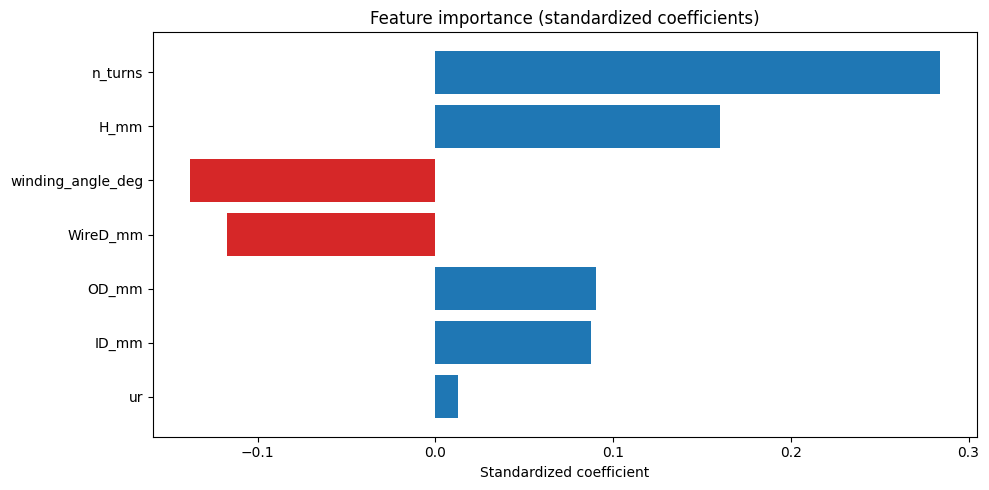

In [57]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = [
    "tab:blue" if c > 0 else "tab:red"
    for c in importance["standardized_coef"]
]
ax.barh(importance["feature"], importance["standardized_coef"], color=colors)
ax.set_xlabel("Standardized coefficient")
ax.set_title("Feature importance (standardized coefficients)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [58]:
# Save sklearn model + metadata
model_best = LinearRegression()
model_best.fit(X_best, y_log)

model_artifact = {
    "model": model_best,
    "feature_cols": feature_cols,
    "transforms": best_transforms,
    "target": "log(L_Leak_uH)",
}

with open("data/best_lr_model.pkl", "wb") as f:
    pickle.dump(model_artifact, f)

print("Model saved to data/best_lr_model.pkl")

Model saved to data/best_lr_model.pkl


## ANN / MLP Model

Using a Multi-Layer Perceptron (MLP) regressor with:
- **Loss function**: MSE
- **Target**: L_Leak_uH (original scale)
- **Feature scaling**: StandardScaler (required for neural networks)
- **Optimizer**: L-BFGS (full-batch, smooth convergence)
- **Evaluation**: Train/Validation split (80/20)

In [59]:
train_val = pd.read_pickle("data/train_val.pkl")

feature_cols = [
    "ur", "OD_mm", "ID_mm", "H_mm", "n_turns", "WireD_mm", "winding_angle_deg"
]
target = "L_Leak_uH"

train_val = train_val.dropna(subset=feature_cols + [target])
X = train_val[feature_cols].copy()
y = train_val[target].copy()

# Train / Validation split (80/20)
RANDOM_STATE = 42
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}")
print(f"Target: {target}")
print(f"Features: {feature_cols}")

Train: (836, 7), Val: (209, 7)
Target: L_Leak_uH
Features: ['ur', 'OD_mm', 'ID_mm', 'H_mm', 'n_turns', 'WireD_mm', 'winding_angle_deg']


## Vanilla MLP baseline

In [60]:
MAX_ITER = 500

mlp = MLPRegressor(
    hidden_layer_sizes=(16,),
    solver="lbfgs",
    alpha=0.0001,
    random_state=RANDOM_STATE,
    warm_start=True,
    max_iter=1,
)

train_mse_history = []
val_mse_history = []
train_r2_history = []
val_r2_history = []

for it in range(MAX_ITER):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        mlp.max_iter = it + 1
        mlp.fit(X_train_scaled, y_train)

    train_pred = mlp.predict(X_train_scaled)
    val_pred = mlp.predict(X_val_scaled)

    train_mse_history.append(mean_squared_error(y_train, train_pred))
    val_mse_history.append(mean_squared_error(y_val, val_pred))
    train_r2_history.append(r2_score(y_train, train_pred))
    val_r2_history.append(r2_score(y_val, val_pred))

In [61]:
train_mse = np.array(train_mse_history)
val_mse = np.array(val_mse_history)
best_epoch = np.argmin(val_mse)

print("Vanilla MLP:")
print("  hidden_layers: (16,), solver: lbfgs, alpha: 0.0001")
print(f"  max_iter: {MAX_ITER}")

print(f"\nBest iteration {best_epoch}:")
print(
    f"  Train MSE: {train_mse[best_epoch]:.6f},"
    f" Val MSE: {val_mse[best_epoch]:.6f}"
)
print(
    f"  Train R\u00b2:  {train_r2_history[best_epoch]:.4f},"
    f" Val R\u00b2:  {val_r2_history[best_epoch]:.4f}"
)

print(f"\nFinal iteration {MAX_ITER}:")
print(f"  Train MSE: {train_mse[-1]:.6f}, Val MSE: {val_mse[-1]:.6f}")
print(f"  Train R\u00b2:  {train_r2_history[-1]:.4f}, Val R\u00b2:  {val_r2_history[-1]:.4f}")

Vanilla MLP:
  hidden_layers: (16,), solver: lbfgs, alpha: 0.0001
  max_iter: 500

Best iteration 34:
  Train MSE: 0.001568, Val MSE: 0.003371
  Train R²:  0.9972, Val R²:  0.9937

Final iteration 500:
  Train MSE: 0.001556, Val MSE: 0.003391
  Train R²:  0.9973, Val R²:  0.9937


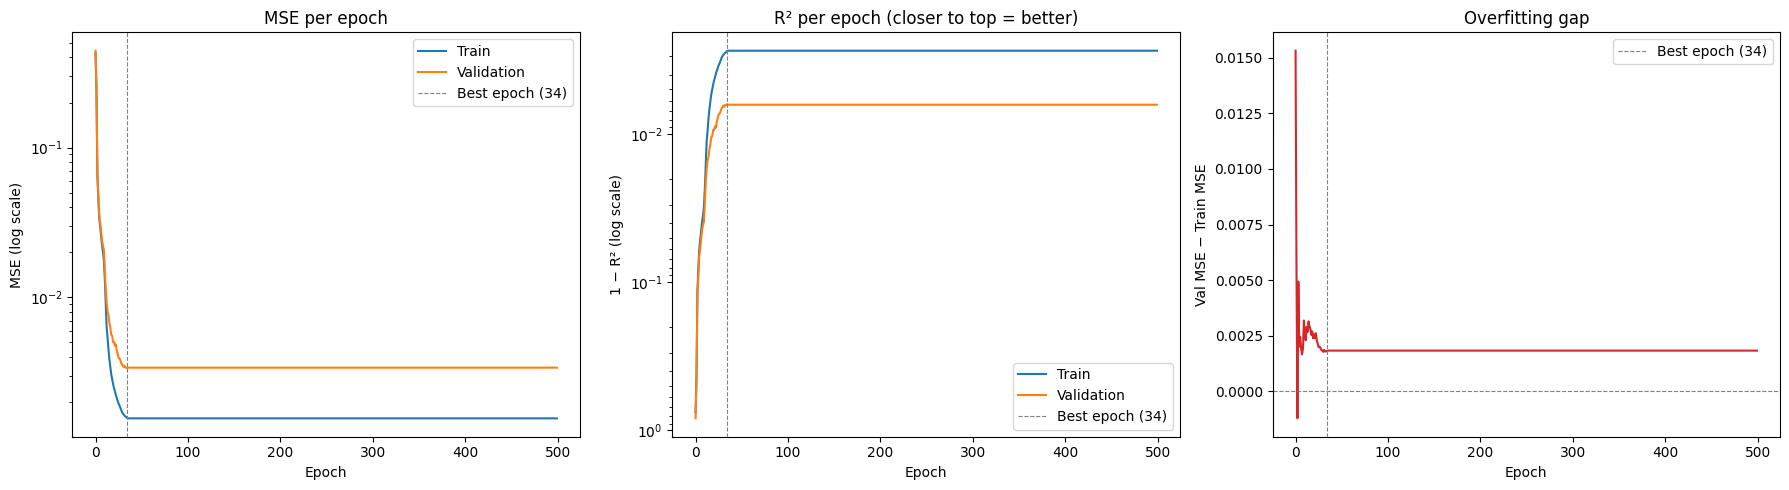

In [62]:
# Learning curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_mse, label="Train")
axes[0].plot(val_mse, label="Validation")
axes[0].axvline(
    best_epoch, color="gray", linestyle="--", linewidth=0.8,
    label=f"Best epoch ({best_epoch})",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE (log scale)")
axes[0].set_title("MSE per epoch")
axes[0].legend()

axes[1].plot(1 - np.array(train_r2_history), label="Train")
axes[1].plot(1 - np.array(val_r2_history), label="Validation")
axes[1].axvline(
    best_epoch, color="gray", linestyle="--", linewidth=0.8,
    label=f"Best epoch ({best_epoch})",
)
axes[1].set_yscale("log")
axes[1].invert_yaxis()
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("1 \u2212 R\u00b2 (log scale)")
axes[1].set_title("R\u00b2 per epoch (closer to top = better)")
axes[1].legend()

axes[2].plot(val_mse - train_mse, color="tab:red")
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[2].axvline(
    best_epoch, color="gray", linestyle="--", linewidth=0.8,
    label=f"Best epoch ({best_epoch})",
)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Val MSE \u2212 Train MSE")
axes[2].set_title("Overfitting gap")
axes[2].legend()

plt.tight_layout()
plt.show()

## Hyperparameter tuning

In [63]:
MAX_ITER = 500

param_grid = {
    "hidden_layer_sizes": [(8,), (16,), (32,), (16, 8), (32, 16)],
    "alpha": [0.0001, 0.001, 0.01, 0.1],
}

keys = list(param_grid.keys())
combos = list(iter_product(*param_grid.values()))
print(f"Total configurations: {len(combos)}")

results = []

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))

    mlp = MLPRegressor(
        hidden_layer_sizes=params["hidden_layer_sizes"],
        solver="lbfgs",
        alpha=params["alpha"],
        random_state=RANDOM_STATE,
        warm_start=True,
        max_iter=1,
    )

    best_val_mse = np.inf
    best_ep = 0
    best_train_mse = np.inf
    best_train_r2 = 0.0
    best_val_r2 = 0.0

    for it in range(MAX_ITER):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            mlp.max_iter = it + 1
            mlp.fit(X_train_scaled, y_train)

        t_pred = mlp.predict(X_train_scaled)
        v_pred = mlp.predict(X_val_scaled)
        t_mse = mean_squared_error(y_train, t_pred)
        v_mse = mean_squared_error(y_val, v_pred)

        if v_mse < best_val_mse:
            best_val_mse = v_mse
            best_train_mse = t_mse
            best_ep = it
            best_train_r2 = r2_score(y_train, t_pred)
            best_val_r2 = r2_score(y_val, v_pred)

    results.append({
        **params,
        "best_iter": best_ep,
        "train_MSE": best_train_mse,
        "val_MSE": best_val_mse,
        "train_R2": best_train_r2,
        "val_R2": best_val_r2,
    })

    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(combos)} done...")

df_hp = pd.DataFrame(results).sort_values("val_MSE").reset_index(drop=True)
print(f"\nTop 10 configurations:")
display(df_hp.head(10))

Total configurations: 20
  5/20 done...
  10/20 done...
  15/20 done...
  20/20 done...

Top 10 configurations:


,hidden_layer_sizes,alpha,best_iter,train_MSE,val_MSE,train_R2,val_R2
0,"(32,)",0.0001,40,0.001165,0.002500,0.997946,0.995318
1,"(32,)",0.0100,39,0.001185,0.002652,0.997910,0.995035
2,"(32,)",0.0010,179,0.001164,0.002696,0.997947,0.994952
3,"(32, 16)",0.1000,59,0.000998,0.002811,0.998241,0.994737
4,"(32,)",0.1000,41,0.001250,0.002860,0.997796,0.994644
5,"(8,)",0.1000,44,0.001671,0.003148,0.997054,0.994105
6,"(16, 8)",0.1000,51,0.001281,0.003303,0.997741,0.993816
7,"(16,)",0.0010,43,0.001474,0.003307,0.997401,0.993809
8,"(16,)",0.0001,34,0.001568,0.003371,0.997236,0.993688
9,"(16,)",0.0100,35,0.001582,0.003397,0.997210,0.993639


### Best architecture: (32, 16)

From the grid search above, the two-layer architecture **(32, 16)** achieved the
best validation MSE. We now fix this architecture and fine-tune the L2
regularization strength (alpha).

In [64]:
MAX_ITER = 500
HIDDEN = (32, 16)

param_grid_2 = {
    "alpha": [0.00001, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1],
}

keys2 = list(param_grid_2.keys())
combos2 = list(iter_product(*param_grid_2.values()))
print(f"Total configurations: {len(combos2)}")

results2 = []

for i, combo in enumerate(combos2):
    params = dict(zip(keys2, combo))

    mlp = MLPRegressor(
        hidden_layer_sizes=HIDDEN,
        solver="lbfgs",
        alpha=params["alpha"],
        random_state=RANDOM_STATE,
        warm_start=True,
        max_iter=1,
    )

    best_val_mse = np.inf
    best_ep = 0
    best_train_mse = np.inf
    best_train_r2 = 0.0
    best_val_r2 = 0.0

    for it in range(MAX_ITER):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            mlp.max_iter = it + 1
            mlp.fit(X_train_scaled, y_train)

        t_pred = mlp.predict(X_train_scaled)
        v_pred = mlp.predict(X_val_scaled)
        t_mse = mean_squared_error(y_train, t_pred)
        v_mse = mean_squared_error(y_val, v_pred)

        if v_mse < best_val_mse:
            best_val_mse = v_mse
            best_train_mse = t_mse
            best_ep = it
            best_train_r2 = r2_score(y_train, t_pred)
            best_val_r2 = r2_score(y_val, v_pred)

    results2.append({
        "hidden_layer_sizes": HIDDEN,
        **params,
        "best_iter": best_ep,
        "train_MSE": best_train_mse,
        "val_MSE": best_val_mse,
        "train_R2": best_train_r2,
        "val_R2": best_val_r2,
    })

    print(
        f"  {i + 1}/{len(combos2)} done"
        f" — alpha={params['alpha']}, val_MSE={best_val_mse:.6f}"
    )

df_hp2 = pd.DataFrame(results2).sort_values("val_MSE").reset_index(drop=True)
print(f"\nAll configurations:")
display(df_hp2)

Total configurations: 8
  1/8 done — alpha=1e-05, val_MSE=0.003791
  2/8 done — alpha=0.0001, val_MSE=0.003435
  3/8 done — alpha=0.0005, val_MSE=0.004164
  4/8 done — alpha=0.001, val_MSE=0.003697
  5/8 done — alpha=0.005, val_MSE=0.003726
  6/8 done — alpha=0.01, val_MSE=0.003611
  7/8 done — alpha=0.05, val_MSE=0.003006
  8/8 done — alpha=0.1, val_MSE=0.002811

All configurations:


,hidden_layer_sizes,alpha,best_iter,train_MSE,val_MSE,train_R2,val_R2
0,"(32, 16)",0.10000,59,0.000998,0.002811,0.998241,0.994737
1,"(32, 16)",0.05000,49,0.000981,0.003006,0.998271,0.994372
2,"(32, 16)",0.00010,53,0.001090,0.003435,0.998079,0.993569
3,"(32, 16)",0.01000,35,0.001214,0.003611,0.997860,0.993239
4,"(32, 16)",0.00100,343,0.001281,0.003697,0.997741,0.993078
5,"(32, 16)",0.00500,48,0.001115,0.003726,0.998033,0.993024
6,"(32, 16)",0.00001,42,0.001203,0.003791,0.997879,0.992902
7,"(32, 16)",0.00050,31,0.001354,0.004164,0.997613,0.992203


In [65]:
# Retrain best configuration and record full learning curves
best_alpha = df_hp2.iloc[0]["alpha"]
print(f"Best config: (32,16), lbfgs, alpha={best_alpha}")

mlp_best = MLPRegressor(
    hidden_layer_sizes=HIDDEN,
    solver="lbfgs",
    alpha=best_alpha,
    random_state=RANDOM_STATE,
    warm_start=True,
    max_iter=1,
)

train_mse_hist = []
val_mse_hist = []
train_r2_hist = []
val_r2_hist = []

for it in range(MAX_ITER):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        mlp_best.max_iter = it + 1
        mlp_best.fit(X_train_scaled, y_train)

    t_pred = mlp_best.predict(X_train_scaled)
    v_pred = mlp_best.predict(X_val_scaled)
    train_mse_hist.append(mean_squared_error(y_train, t_pred))
    val_mse_hist.append(mean_squared_error(y_val, v_pred))
    train_r2_hist.append(r2_score(y_train, t_pred))
    val_r2_hist.append(r2_score(y_val, v_pred))

train_mse_arr = np.array(train_mse_hist)
val_mse_arr = np.array(val_mse_hist)
best_ep = np.argmin(val_mse_arr)

Best config: (32,16), lbfgs, alpha=0.1


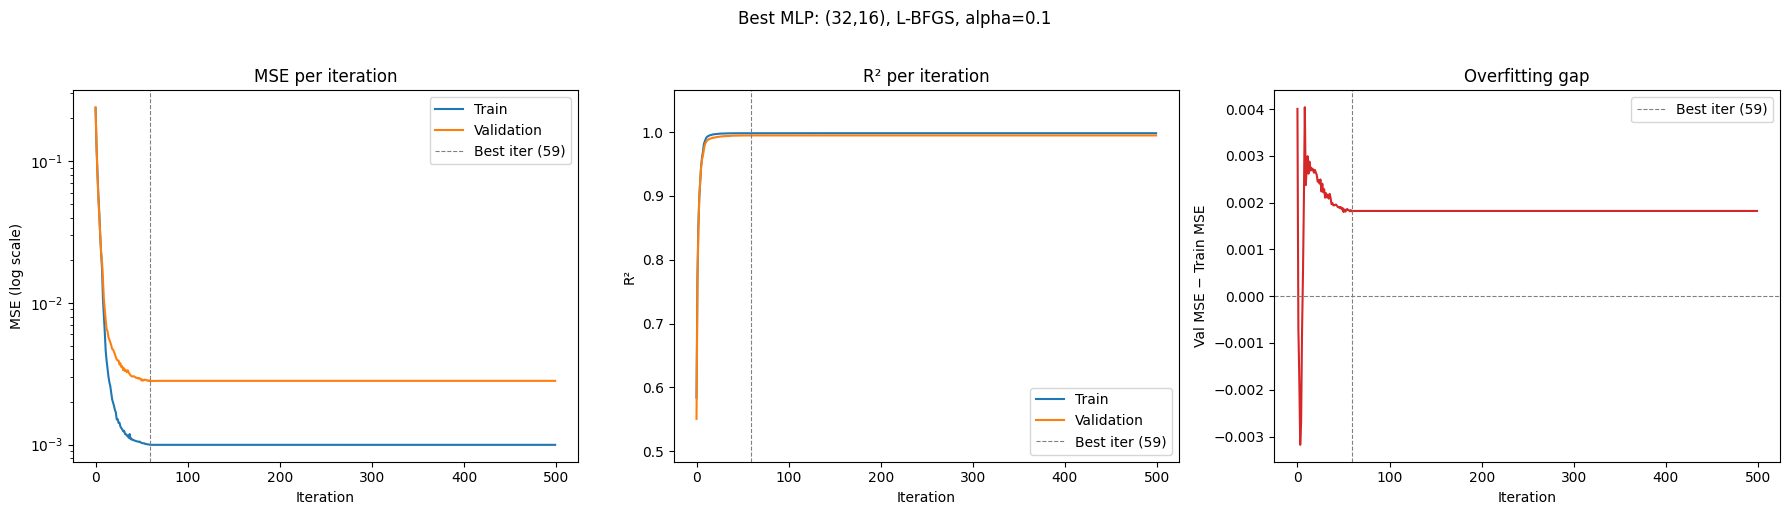


Best iteration 59:
  Train MSE: 0.000998, Val MSE: 0.002811
  Train R²:  0.9982, Val R²:  0.9947


In [66]:
# Learning curves for best MLP
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_mse_arr, label="Train")
axes[0].plot(val_mse_arr, label="Validation")
axes[0].axvline(
    best_ep, color="gray", linestyle="--", linewidth=0.8,
    label=f"Best iter ({best_ep})",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE (log scale)")
axes[0].set_title("MSE per iteration")
axes[0].legend()

r2_all = train_r2_hist + val_r2_hist
r2_min = min(r2_all)
r2_max = max(r2_all)
r2_pad = max((r2_max - r2_min) * 0.15, 0.001)
axes[1].plot(train_r2_hist, label="Train")
axes[1].plot(val_r2_hist, label="Validation")
axes[1].axvline(
    best_ep, color="gray", linestyle="--", linewidth=0.8,
    label=f"Best iter ({best_ep})",
)
axes[1].set_ylim(r2_min - r2_pad, r2_max + r2_pad)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("R\u00b2")
axes[1].set_title("R\u00b2 per iteration")
axes[1].legend()

gap = val_mse_arr - train_mse_arr
axes[2].plot(gap, color="tab:red")
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[2].axvline(
    best_ep, color="gray", linestyle="--", linewidth=0.8,
    label=f"Best iter ({best_ep})",
)
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Val MSE \u2212 Train MSE")
axes[2].set_title("Overfitting gap")
axes[2].legend()

plt.suptitle(
    f"Best MLP: (32,16), L-BFGS, alpha={best_alpha}", y=1.02
)
plt.tight_layout()
plt.show()

print(f"\nBest iteration {best_ep}:")
print(
    f"  Train MSE: {train_mse_arr[best_ep]:.6f},"
    f" Val MSE: {val_mse_arr[best_ep]:.6f}"
)
print(
    f"  Train R\u00b2:  {train_r2_hist[best_ep]:.4f},"
    f" Val R\u00b2:  {val_r2_hist[best_ep]:.4f}"
)

In [67]:
mlp_artifact = {
    "model": mlp_best,
    "scaler": scaler,
    "feature_cols": feature_cols,
    "target": target,
    "hidden_layer_sizes": HIDDEN,
    "alpha": best_alpha,
    "best_iter": best_ep,
}

with open("data/best_mlp_model.pkl", "wb") as f:
    pickle.dump(mlp_artifact, f)

print("Model saved to data/best_mlp_model.pkl")
print(f"  Architecture: {HIDDEN}, alpha: {best_alpha}, best iter: {best_ep}")

Model saved to data/best_mlp_model.pkl
  Architecture: (32, 16), alpha: 0.1, best iter: 59


# Test Set Evaluation

Evaluate the best Linear Regression and MLP models on the held-out test set to
assess generalization performance.

- **Linear Regression**: log target with best feature transforms (loaded from `best_lr_model.pkl`)
- **MLP**: (32, 16) architecture with L-BFGS, best alpha from tuning

In [68]:
# Load full train+val and test sets
train_val_full = pd.read_pickle("data/train_val.pkl")
test = pd.read_pickle("data/test.pkl")

train_val_full = train_val_full.dropna(subset=feature_cols + [target])
test = test.dropna(subset=feature_cols + [target])

X_trainval = train_val_full[feature_cols].copy()
y_trainval = train_val_full[target].copy()
X_test = test[feature_cols].copy()
y_test = test[target].copy()

print(f"Train+Val: {X_trainval.shape[0]} samples")
print(f"Test:      {X_test.shape[0]} samples")

Train+Val: 1045 samples
Test:      262 samples


In [69]:
# --- Retrain Linear Regression on full train+val ---
with open("data/best_lr_model.pkl", "rb") as f:
    lr_artifact = pickle.load(f)

lr_transforms = lr_artifact["transforms"]
print(f"LR transforms: {lr_transforms}")

# Apply feature transforms
X_trainval_lr = X_trainval.copy()
X_test_lr = X_test.copy()
for col in feature_cols:
    X_trainval_lr[col] = transformations[lr_transforms[col]](X_trainval_lr[col])
    X_test_lr[col] = transformations[lr_transforms[col]](X_test_lr[col])

y_trainval_log = np.log(y_trainval)
y_test_log = np.log(y_test)

lr_final = LinearRegression()
lr_final.fit(X_trainval_lr, y_trainval_log)

y_pred_lr_log = lr_final.predict(X_test_lr)
y_pred_lr = np.exp(y_pred_lr_log)

# Log-space metrics (comparable to validation metrics)
lr_test_mse_log = mean_squared_error(y_test_log, y_pred_lr_log)
lr_test_r2_log = r2_score(y_test_log, y_pred_lr_log)

# Original-scale metrics
lr_test_mse = mean_squared_error(y_test, y_pred_lr)
lr_test_r2 = r2_score(y_test, y_pred_lr)
lr_test_mape = mean_absolute_percentage_error(y_test, y_pred_lr)

print(f"\nLinear Regression (log target + transforms) — retrained on full train+val:")
print(
    f"  Log-space (comparable to val):"
    f"  MSE={lr_test_mse_log:.6f}, R\u00b2={lr_test_r2_log:.4f}"
)
print(
    f"  Original-scale:"
    f"                 MSE={lr_test_mse:.6f},"
    f" R\u00b2={lr_test_r2:.4f}, MAPE={lr_test_mape:.4f}"
)

LR transforms: {'ur': 'log', 'OD_mm': 'log', 'ID_mm': 'log', 'H_mm': 'log', 'n_turns': 'log', 'WireD_mm': 'log', 'winding_angle_deg': 'sqrt'}

Linear Regression (log target + transforms) — retrained on full train+val:
  Log-space (comparable to val):  MSE=0.006810, R²=0.9661
  Original-scale:                 MSE=0.057396, R²=0.8948, MAPE=0.0532


In [70]:
# --- Retrain MLP on full train+val ---
scaler_final = StandardScaler()
X_trainval_scaled = scaler_final.fit_transform(X_trainval)
X_test_scaled = scaler_final.transform(X_test)

mlp_final = MLPRegressor(
    hidden_layer_sizes=HIDDEN,
    solver="lbfgs",
    alpha=best_alpha,
    random_state=RANDOM_STATE,
    max_iter=MAX_ITER,
)
mlp_final.fit(X_trainval_scaled, y_trainval)

y_pred_mlp = mlp_final.predict(X_test_scaled)

mlp_test_mse = mean_squared_error(y_test, y_pred_mlp)
mlp_test_r2 = r2_score(y_test, y_pred_mlp)
mlp_test_mape = mean_absolute_percentage_error(y_test, y_pred_mlp)

print(
    f"MLP (32, 16), L-BFGS, alpha={best_alpha}"
    f" — retrained on full train+val:"
)
print(
    f"  Original-scale:"
    f"  MSE={mlp_test_mse:.6f},"
    f" R\u00b2={mlp_test_r2:.4f}, MAPE={mlp_test_mape:.4f}"
)

MLP (32, 16), L-BFGS, alpha=0.1 — retrained on full train+val:
  Original-scale:  MSE=0.001069, R²=0.9980, MAPE=0.0105


In [71]:
mu0 = 4 * np.pi * 1e-7  # H/m

def nave_heldwein_predict(X):
    OD = X["OD_mm"].to_numpy(dtype=float)* 1e-3
    ID = X["ID_mm"].to_numpy(dtype=float)* 1e-3
    H  = X["H_mm"].to_numpy(dtype=float)* 1e-3
    N  = X["n_turns"].to_numpy(dtype=float)
    wireOD = X["WireD_mm"].to_numpy(dtype=float)* 1e-3

    # Ae exactly like she used
    Ae = H * (OD - ID) / 2.0

    # theta EXACTLY like her screenshot (OD in numerator!)
    theta = 2.0 * N * OD / (ID - wireOD)

    leff = np.sqrt(
        (OD**2 / np.sqrt(2.0)) * (theta/4.0 + 1.0 + np.sin(theta/2.0))**2
        + (ID**2) * (theta/4.0 - 1.0 + np.sin(theta/2.0))**2
    )

    Lair = mu0 * (N**2) * Ae / leff

    # le EXACTLY like her screenshot (log mean path length)
    le = np.pi * (OD - ID) / np.log(OD / ID)

    mueff = 2.5 * ((le/2.0) * np.sqrt(np.pi / Ae))**1.45

    return Lair * mueff


y_pred_nave = nave_heldwein_predict(X_test)* 1e6

In [72]:
nave_test_mse = mean_squared_error(y_test, y_pred_nave)
nave_test_r2 = r2_score(y_test, y_pred_nave)
nave_test_mape = np.mean(np.abs((y_pred_nave - y_test.values) / y_test.values))

comparison_test = pd.DataFrame([
    {
        "Model": "Nave/Heldwein (analytical)",
        "Test MSE": nave_test_mse,
        "Test R²": nave_test_r2,
        "Test MAPE": nave_test_mape,
        "Test MSE (log-space)": mean_squared_error(
            y_test_log, np.log(np.clip(y_pred_nave, 1e-10, None))
        ),
        "Test R² (log-space)": r2_score(
            y_test_log, np.log(np.clip(y_pred_nave, 1e-10, None))
        ),
    },
    {
        "Model": "Linear Regression (log target + transforms)",
        "Test MSE": lr_test_mse,
        "Test R²": lr_test_r2,
        "Test MAPE": lr_test_mape,
        "Test MSE (log-space)": lr_test_mse_log,
        "Test R² (log-space)": lr_test_r2_log,
    },
    {
        "Model": f"MLP (32, 16), alpha={best_alpha}",
        "Test MSE": mlp_test_mse,
        "Test R²": mlp_test_r2,
        "Test MAPE": mlp_test_mape,
        "Test MSE (log-space)": mean_squared_error(
            y_test_log, np.log(np.clip(y_pred_mlp, 1e-10, None))
        ),
        "Test R² (log-space)": r2_score(
            y_test_log, np.log(np.clip(y_pred_mlp, 1e-10, None))
        ),
    },
])

display(comparison_test)

,Model,Test MSE,Test R²,Test MAPE,Test MSE (log-space),Test R² (log-space)
0,Nave/Heldwein (analytical),1.020551,-0.870680,0.541780,0.214483,-0.067264
1,Linear Regression (log target + transforms),0.057396,0.894792,0.053182,0.006810,0.966113
2,"MLP (32, 16), alpha=0.1",0.001069,0.998041,0.010545,0.000332,0.998348


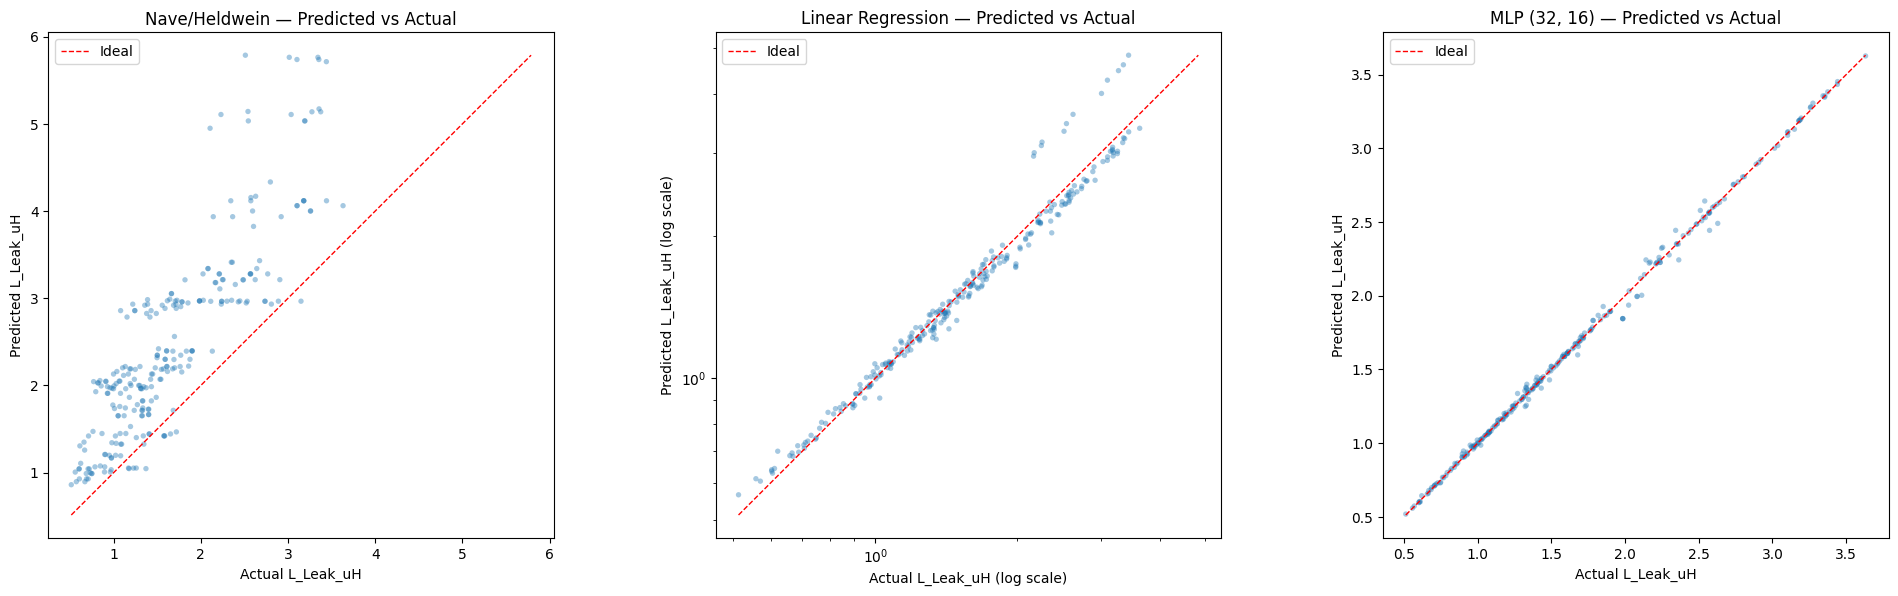

In [73]:
# Predicted vs actual
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Nave/Heldwein — normal scale
ax = axes[0]
ax.scatter(y_test, y_pred_nave, alpha=0.4, s=15, edgecolors="none")
lims = [min(y_test.min(), min(y_pred_nave)), max(y_test.max(), max(y_pred_nave))]
ax.plot(lims, lims, "r--", linewidth=1, label="Ideal")
ax.set_xlabel("Actual L_Leak_uH")
ax.set_ylabel("Predicted L_Leak_uH")
ax.set_title("Nave/Heldwein — Predicted vs Actual")
ax.legend()
ax.set_aspect("equal", adjustable="box")

# LinReg — log scale
ax = axes[1]
ax.scatter(y_test, y_pred_lr, alpha=0.4, s=15, edgecolors="none")
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
ax.plot(lims, lims, "r--", linewidth=1, label="Ideal")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual L_Leak_uH (log scale)")
ax.set_ylabel("Predicted L_Leak_uH (log scale)")
ax.set_title("Linear Regression — Predicted vs Actual")
ax.legend()
ax.set_aspect("equal", adjustable="box")

# MLP — standard scale
ax = axes[2]
ax.scatter(y_test, y_pred_mlp, alpha=0.4, s=15, edgecolors="none")
lims = [min(y_test.min(), y_pred_mlp.min()), max(y_test.max(), y_pred_mlp.max())]
ax.plot(lims, lims, "r--", linewidth=1, label="Ideal")
ax.set_xlabel("Actual L_Leak_uH")
ax.set_ylabel("Predicted L_Leak_uH")
ax.set_title("MLP (32, 16) — Predicted vs Actual")
ax.legend()
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

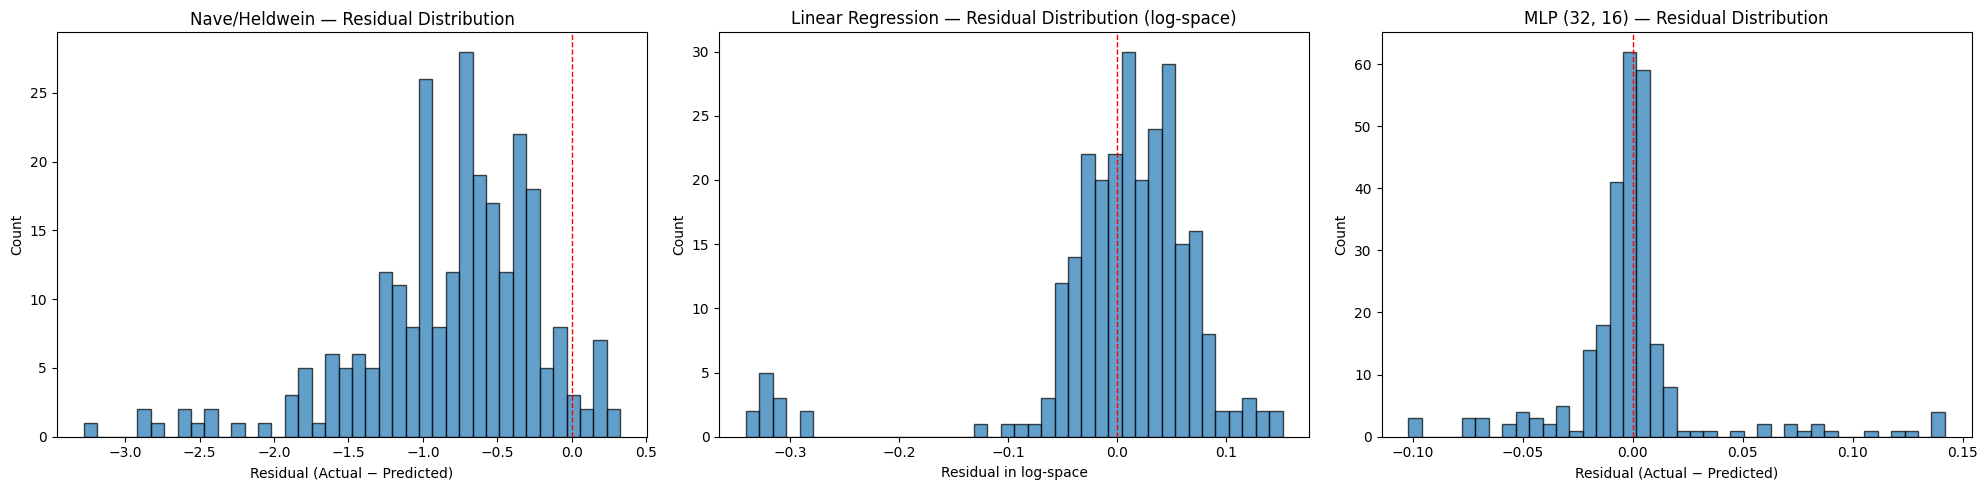

In [74]:
# Residual distributions
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Nave/Heldwein — residuals in original scale
residuals_nave = y_test.values - y_pred_nave
axes[0].hist(residuals_nave, bins=40, edgecolor="black", alpha=0.7)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Residual (Actual − Predicted)")
axes[0].set_ylabel("Count")
axes[0].set_title("Nave/Heldwein — Residual Distribution")

# LinReg — residuals in log space
residuals_lr_log = y_test_log - y_pred_lr_log
axes[1].hist(residuals_lr_log, bins=40, edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Residual in log-space")
axes[1].set_ylabel("Count")
axes[1].set_title("Linear Regression — Residual Distribution (log-space)")

# MLP — residuals in original scale
residuals_mlp = y_test - y_pred_mlp
axes[2].hist(residuals_mlp, bins=40, edgecolor="black", alpha=0.7)
axes[2].axvline(0, color="red", linestyle="--", linewidth=1)
axes[2].set_xlabel("Residual (Actual − Predicted)")
axes[2].set_ylabel("Count")
axes[2].set_title("MLP (32, 16) — Residual Distribution")

plt.tight_layout()
plt.show()

## Sample-level comparison: all three models

Compare the Nave/Heldwein analytical model, Linear Regression, and MLP predictions
on every test sample, with percentage errors.

In [75]:
sample_comparison = X_test.copy()
sample_comparison["Actual (uH)"] = y_test.values
sample_comparison["Nave/Heldwein (uH)"] = y_pred_nave
sample_comparison["LinReg (uH)"] = y_pred_lr
sample_comparison["MLP (uH)"] = y_pred_mlp

# Percentage errors: (predicted - actual) / actual * 100
sample_comparison["Nave/Heldwein Error (%)"] = (
    (y_pred_nave - y_test.values) / y_test.values * 100
)
sample_comparison["LinReg Error (%)"] = (
    (y_pred_lr - y_test.values) / y_test.values * 100
)
sample_comparison["MLP Error (%)"] = (
    (y_pred_mlp - y_test.values) / y_test.values * 100
)

# Display columns: inputs + predictions + errors
display_cols = (
    feature_cols
    + [
        "Actual (uH)",
        "Nave/Heldwein (uH)", "Nave/Heldwein Error (%)",
        "LinReg (uH)", "LinReg Error (%)",
        "MLP (uH)", "MLP Error (%)",
    ]
)

styled = (
    sample_comparison[display_cols]
    .style
    .format({
        col: "{:.3f}" for col in feature_cols
    } | {
        "Actual (uH)": "{:.4f}",
        "Nave/Heldwein (uH)": "{:.4f}",
        "LinReg (uH)": "{:.4f}",
        "MLP (uH)": "{:.4f}",
        "Nave/Heldwein Error (%)": "{:+.2f}%",
        "LinReg Error (%)": "{:+.2f}%",
        "MLP Error (%)": "{:+.2f}%",
    })
    .background_gradient(
        subset=["Nave/Heldwein Error (%)", "LinReg Error (%)", "MLP Error (%)"],
        cmap="RdYlGn_r", vmin=-50, vmax=50,
    )
)

display(styled)

# Summary statistics
print("\nMean Absolute Percentage Error (MAPE):")
for name, col in [
    ("Nave/Heldwein", "Nave/Heldwein Error (%)"),
    ("LinReg", "LinReg Error (%)"),
    ("MLP", "MLP Error (%)"),
]:
    mape = sample_comparison[col].abs().mean()
    print(f"  {name:>15s}: {mape:.2f}%")

,ur,OD_mm,ID_mm,H_mm,n_turns,WireD_mm,winding_angle_deg,Actual (uH),Nave/Heldwein (uH),Nave/Heldwein Error (%),LinReg (uH),LinReg Error (%),MLP (uH),MLP Error (%)
316,9627.497,85.800,44.600,25.500,8.000,2.305,90.000,2.2343,2.9328,+31.27%,2.1350,-4.44%,2.2399,+0.25%
148,9627.497,51.200,24.000,21.000,8.000,2.305,110.000,1.1927,1.5281,+28.12%,1.2205,+2.33%,1.2056,+1.08%
205,9627.497,57.500,37.700,24.100,8.000,2.588,110.000,1.5003,2.3463,+56.38%,1.4958,-0.30%,1.5217,+1.43%
6,16470.889,32.800,17.600,12.500,8.000,1.291,90.000,0.9499,1.1981,+26.13%,0.9076,-4.45%,0.9869,+3.89%
244,9627.497,95.400,54.700,24.700,8.000,2.906,70.000,2.5313,2.9655,+17.15%,2.3389,-7.60%,2.5327,+0.05%
287,7264.915,95.400,54.700,24.700,8.000,4.115,110.000,1.6435,2.9893,+81.89%,1.5582,-5.19%,1.6410,-0.15%
999,4461.991,57.500,37.700,24.100,6.000,2.305,110.000,0.9282,1.9855,+113.90%,0.9692,+4.41%,0.9387,+1.13%
139,9627.497,51.200,24.000,21.000,8.000,1.628,110.000,1.4018,1.6656,+18.82%,1.3792,-1.61%,1.3967,-0.36%
1220,10783.563,64.500,36.800,26.200,6.000,2.305,50.000,1.6168,2.1597,+33.58%,1.6454,+1.77%,1.6203,+0.22%
401,7264.915,67.300,46.500,28.600,8.000,2.906,70.000,2.4827,3.2113,+29.34%,2.3260,-6.31%,2.4834,+0.03%



Mean Absolute Percentage Error (MAPE):
    Nave/Heldwein: 54.18%
           LinReg: 5.32%
              MLP: 1.05%


In [76]:
# === Linear Regression formula ===
print("=" * 60)
print("Linear Regression \u2014 Final Model (retrained on full train+val)")
print(f"  Test MSE (log-space): {lr_test_mse_log:.6f}")
print(f"  Test R\u00b2  (log-space): {lr_test_r2_log:.4f}")
print(f"  Test MSE (original):  {lr_test_mse:.6f}")
print(f"  Test R\u00b2  (original):  {lr_test_r2:.4f}")
print("=" * 60)

transform_map = {
    "none": "{col}",
    "log": "log(1 + {col})",
    "sqrt": "sqrt({col})",
    "squared": "{col}\u00b2",
}

print(f"\nlog(L_Leak_uH) =")
print(f"    {lr_final.intercept_:.6f}")
for col, coef in zip(feature_cols, lr_final.coef_):
    t = lr_transforms[col]
    feat = transform_map[t].format(col=col)
    sign = "+" if coef >= 0 else "-"
    print(f"  {sign} {abs(coef):.6f} * {feat}")

print(f"\nTransforms: {lr_transforms}")
print(f"Intercept:  {lr_final.intercept_:.6f}")
print("Coefficients:")
for col, coef in zip(feature_cols, lr_final.coef_):
    print(f"  {col:>20s} ({lr_transforms[col]:>7s}): {coef:.6f}")

Linear Regression — Final Model (retrained on full train+val)
  Test MSE (log-space): 0.006810
  Test R²  (log-space): 0.9661
  Test MSE (original):  0.057396
  Test R²  (original):  0.8948

log(L_Leak_uH) =
    -6.695441
  + 0.021110 * log(1 + ur)
  + 0.266820 * log(1 + OD_mm)
  + 0.223047 * log(1 + ID_mm)
  + 0.905113 * log(1 + H_mm)
  + 1.836474 * log(1 + n_turns)
  - 0.533166 * log(1 + WireD_mm)
  - 0.120869 * sqrt(winding_angle_deg)

Transforms: {'ur': 'log', 'OD_mm': 'log', 'ID_mm': 'log', 'H_mm': 'log', 'n_turns': 'log', 'WireD_mm': 'log', 'winding_angle_deg': 'sqrt'}
Intercept:  -6.695441
Coefficients:
                    ur (    log): 0.021110
                 OD_mm (    log): 0.266820
                 ID_mm (    log): 0.223047
                  H_mm (    log): 0.905113
               n_turns (    log): 1.836474
              WireD_mm (    log): -0.533166
     winding_angle_deg (   sqrt): -0.120869


In [77]:
# === MLP weights ===
print("=" * 60)
print(f"MLP (32, 16) \u2014 Final Model (retrained on full train+val)")
print(f"  alpha={best_alpha}, solver=lbfgs, max_iter={MAX_ITER}")
print(f"  Test MSE: {mlp_test_mse:.6f}")
print(f"  Test R\u00b2:  {mlp_test_r2:.4f}")
print("=" * 60)

print(f"\nScaler (StandardScaler) fitted on train+val:")
print(f"  {'Feature':>20s}  {'Mean':>12s}  {'Std':>12s}")
for col, m, s in zip(feature_cols, scaler_final.mean_, scaler_final.scale_):
    print(f"  {col:>20s}  {m:12.6f}  {s:12.6f}")

for i, (W, b) in enumerate(zip(mlp_final.coefs_, mlp_final.intercepts_)):
    layer_in = W.shape[0]
    layer_out = W.shape[1]
    activation = (
        "relu" if i < len(mlp_final.coefs_) - 1 else "identity"
    )
    print(
        f"\nLayer {i + 1}: ({layer_in} -> {layer_out}),"
        f" activation={activation}"
    )
    print(f"  Weights shape: {W.shape}")
    print(f"  Biases shape:  {b.shape}")
    print("  Weight matrix:")
    print(
        pd.DataFrame(W).to_string(
            index=True, float_format=lambda x: f"{x:.6f}"
        )
    )
    print(f"  Biases: {np.array2string(b, precision=6, separator=', ')}")

MLP (32, 16) — Final Model (retrained on full train+val)
  alpha=0.1, solver=lbfgs, max_iter=500
  Test MSE: 0.001069
  Test R²:  0.9980

Scaler (StandardScaler) fitted on train+val:
               Feature          Mean           Std
                    ur   9477.190754   5237.884474
                 OD_mm     71.679234     23.071562
                 ID_mm     41.806220     16.120297
                  H_mm     23.936842      4.088101
               n_turns      7.261244      1.308668
              WireD_mm      2.537824      0.768579
     winding_angle_deg     88.660287     20.610872

Layer 1: (7 -> 32), activation=relu
  Weights shape: (7, 32)
  Biases shape:  (32,)
  Weight matrix:
         0         1         2         3         4         5         6         7         8         9         10        11        12        13        14        15        16        17        18        19        20        21        22        23        24        25        26        27        28        29      